# NAVA YOLO 데이터 처리 통합 

이 노트북은 NAVA YOLO Peak Detection을 위한 전체 데이터 처리 파이프라인을 통합한 것입니다.
이 과정을 통해 Raw 데이터 정제부터 YOLO 학습 데이터 생성까지 한 번에 수행할 수 있습니다.

## 주요 단계 (Steps)
1. **Raw 데이터 정제 (Refine Raw Data)**: Raw Edi 신호를 불러와 중복을 제거하고 10ms 간격의 마스터 그리드에 맞춰 정제합니다.
2. **GT Peak 정제 (Refine GT Peaks)**: Breath-by-Breath (BbB) 라벨과 전문가 검토(FP/FN) 데이터를 병합하여 최종 정답(Ground Truth)을 생성합니다.
3. **YOLO 데이터 생성 (Generate YOLO Data)**: 정제된 데이터와 정제된 Peak를 사용하여 Sliding Window 방식으로 YOLO 학습용 이미지와 라벨을 생성합니다.

**참고**: 환자 ID(PID)는 `03`부터 `20`까지 총 17명이 하드코딩 되어 있습니다.

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import glob
import json
import random
from PIL import Image
from tqdm.auto import tqdm

# --- 설정 (Configuration) ---
# 기본 경로 설정
BASE_DIR = "/home/jhkim/NAVA/NAVA_original"
RAW_DATA_SOURCE = os.path.join(BASE_DIR, "000_CNN_PeakDetectionData/Edi_sample")      # 원본 데이터 경로
REVIEW_DATA_SOURCE = os.path.join(BASE_DIR, "000_CNN_PeakDetectionData/Edi_peak_review") # 전문가 리뷰 데이터 경로

# Check if path exists
if not os.path.exists(RAW_DATA_SOURCE):
    raise FileNotFoundError(f"원본 데이터 경로를 찾을 수 없습니다: {RAW_DATA_SOURCE}")
# 결과 저장 경로 (현재 폴더의 data 하위 폴더)
OUTPUT_ROOT = "/home/jhkim/NAVA/02_YOLO/data"
REFINED_RAW_DIR = os.path.join(OUTPUT_ROOT, "1_Refined_Raw")   # 단계 1 결과 저장
REFINED_PEAKS_DIR = os.path.join(OUTPUT_ROOT, "2_Refined_Peaks") # 단계 2 결과 저장
YOLO_DATA_DIR = os.path.join(OUTPUT_ROOT, "3_YOLO_Data")       # 단계 3 결과 저장

# 폴더가 없으면 생성
for d in [REFINED_RAW_DIR, REFINED_PEAKS_DIR, YOLO_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

# 대상 환자 ID 리스트 (17명)
PIDS = ["03", "04", "05", "07", "08", "09", "10", "11", "12", "13", 
        "14", "15", "16", "17", "18", "19", "20"]

# 상수 설정
EXPECTED_INTERVAL = 10  # 데이터 샘플링 간격 (10ms)
ERROR_VALUE = 32511     # 에러 값 (사용되지 않음)
WINDOW_SIZE = 2000      # YOLO 학습용 윈도우 크기 (2000개 포인트 = 20초)
STRIDE = 1000           # 윈도우 이동 간격 (1000개 포인트 = 10초)
PADDING = 2             # 이미지 생성 시 Y축 여유 공간 (값 보정용)

print(f"결과 저장 경로: {OUTPUT_ROOT}")
print(f"대상 환자 ({len(PIDS)}명): {PIDS}")


결과 저장 경로: /home/jhkim/NAVA/02_YOLO/data
대상 환자 (17명): ['03', '04', '05', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


## 단계 1: Raw 데이터 정제 (Refine Raw Data)
이 단계에서는 다음 작업을 수행합니다:
1. 환자별 Raw Excel 파일들을 모두 불러옵니다.
2. 타임스탬프 중복을 확인하고 처리합니다 (중복 시 모두 제거 -> 결측치 처리).
3. 10ms 간격의 마스터 그리드를 생성하여 데이터를 매핑합니다.
4. 비어있는 값(NaN)의 개수와 비율을 계산하여 출력합니다.

In [12]:
def normalize_string(s):
    """문자열 정규화: 소문자로 변환하고 특수문자 제거"""
    s = str(s).lower()
    return re.sub(r'[^a-z0-9]', '', s)

def find_data_start_and_load(file_path, keywords=['timestamp', 'edi']):
    """Excel 파일에서 실제 데이터가 시작되는 헤더 위치를 찾아 데이터를 로드합니다."""
    try:
        # 처음 50줄만 읽어서 헤더 위치 탐색
        temp_df = pd.read_excel(file_path, nrows=50, engine='openpyxl', header=None)
    except:
        return pd.DataFrame()

    header_row = -1
    found_indices = {}
    
    # 행을 순회하며 키워드(timestamp, edi)가 모두 포함된 행을 찾음
    for i, row in temp_df.iterrows():
        row_vals = [normalize_string(v) if pd.notna(v) else "" for v in row.values]
        matched = {}
        for kw in keywords:
            idx = [j for j, v in enumerate(row_vals) if kw in v]
            if idx: matched[kw] = idx[0]
        if len(matched) == len(keywords):
            header_row = i
            found_indices = matched
            break
    
    if header_row != -1:
        # 헤더 위치부터 다시 데이터 로드
        df = pd.read_excel(file_path, skiprows=header_row, engine='openpyxl')
        
        # 필요한 컬럼만 선택하고 이름 변경
        cols_to_use = [df.columns[found_indices[kw]] for kw in keywords]
        res = df[cols_to_use].copy()
        res.columns = keywords
        
        # 숫자형으로 변환 (에러 발생 시 NaN 처리)
        for col in keywords:
            res[col] = pd.to_numeric(res[col], errors='coerce')
            
        # 에러 값 제거
        if 'edi' in keywords:
            res = res[res['edi'] != ERROR_VALUE]
            
        return res.dropna(subset=[keywords[0]]) # 안전장치(ts가 비어 있으면, 그냥 과감하게 버리라는 뜻. 뒤에가서 다 Ts를 기준으로 전처리를 하기 때문이다.)

    return pd.DataFrame(columns=keywords)

def refine_raw_data(pid):
    """특정 환자의 Raw 데이터를 정제하여 저장하고 통계를 반환합니다."""
    
    # 1. 환자 폴더 내의 모든 Raw 파일 로드
    patient_folder = os.path.join(RAW_DATA_SOURCE, pid)
    file_pattern = os.path.join(patient_folder, f"edi-{pid}-raw-*.xlsx")
    # 파일명 끝의 숫자를 기준으로 정렬
    files = sorted(glob.glob(file_pattern), key=lambda x: int(re.search(r'[-_](\d+)\.xlsx$', x).group(1)) if re.search(r'[-_](\d+)\.xlsx$', x) else 0)
    
    if not files:
        print(f"PID {pid}의 파일을 찾을 수 없습니다.")
        return None
        
    df_list = []
    for f in files:
        df_list.append(find_data_start_and_load(f))
        
    full_raw_df = pd.concat(df_list, ignore_index=True)
    full_raw_df.dropna(subset=['timestamp'], inplace=True)
    full_raw_df.sort_values('timestamp', inplace=True) # row가 같은 값을 가져도, 하나로 뭉쳐지지는 않는다.(문제x)

    # 2. 중복 처리 및 정수 변환
    # 타임스탬프를 정수(ms)로 반올림
    full_raw_df['timestamp'] = full_raw_df['timestamp'].round().astype(int)
    
    # 중복된 타임스탬프 모두 제거 (keep=False) -> 마스터 그리드 병합 시 NaN이 됨
    full_raw_df = full_raw_df.drop_duplicates(subset=['timestamp'], keep=False)
    
    # 3. 마스터 그리드(Master Grid) 생성
    # 전체 시간 범위를 10ms 간격으로 생성
    t_min = round(full_raw_df['timestamp'].min() / 10) * 10
    t_max = round(full_raw_df['timestamp'].max() / 10) * 10
    master_ts = np.arange(t_min, t_max + EXPECTED_INTERVAL, EXPECTED_INTERVAL).astype(int)
    
    output_df = pd.DataFrame({'timestamp': master_ts})
    # 마스터 그리드에 원본 데이터 매핑 (없는 시간대는 NaN이 됨)
    output_df = pd.merge(output_df, full_raw_df[['timestamp', 'edi']], on='timestamp', how='left')
    
    # 4. 결측치(Missing) 통계 계산
    total_rows = len(output_df)
    missing_count = output_df['edi'].isna().sum()
    missing_ratio = (missing_count / total_rows) * 100
    
    # 결과 저장
    save_path = os.path.join(REFINED_RAW_DIR, f"{pid}.xlsx")
    output_df.to_excel(save_path, index=False)
    
    return {
        'pid': pid,
        'total_rows': total_rows,
        'missing_count': missing_count,
        'missing_ratio': missing_ratio
    }

In [ ]:
# 단계 1 실행
raw_stats = []
print(f"{'PID':<5} | {'결측치(개)':<10} | {'결측비율(%)':<10}")
print("-" * 35)

for pid in tqdm(PIDS, desc="Raw 데이터 정제 중"):
    stat = refine_raw_data(pid)
    if stat:
        raw_stats.append(stat)
        print(f"{stat['pid']:<5} | {stat['missing_count']:<10} | {stat['missing_ratio']:.2f}%")

PID   | 결측치(개)     | 결측비율(%)   
-----------------------------------


Raw 데이터 정제 중:   0%|          | 0/17 [00:00<?, ?it/s]

## 단계 2: GT Peak 정제 (Refine Ground Truth Peaks)
전문가가 1차로 라벨링한 'Breath-by-Breath (BbB)' 데이터와 전문가가 검토한 'FP/FN' 데이터를 결합합니다.

**정제 로직 (Logic)**:
- **최종 Peak** = **set(기존 gt인 BbB의 timestamps)** - **set({FN,x}인 timestamps)** + **set({FP,o}인 timestamps)**
  - `FN_to_remove`: 전문가가 'x'라고 표시한 FN (실제 Peak 아님) -> 로직상 제거 대상
  - `FP_to_add`: 전문가가 'o'라고 표시한 FP (실제 Peak 맞음) -> 로직상 추가 대상
- **시각화**: 정제된 Raw 데이터 위에 **제거된 Peak(빨간색 X)**와 **추가된 Peak(초록색 O)**를 표시하여 검증합니다.

In [7]:
def refine_gt_peaks(pid, visualize=False):
    """BbB 데이터와 전문가 검토를 병합하여 GT를 정제하고, 변경사항을 반환합니다."""
    # 1. BbB(1차 전문가 라벨링) 데이터 로드
    bbb_path = os.path.join(REVIEW_DATA_SOURCE, f"edi-{pid}_ST vs. BbB.xlsx")
    if not os.path.exists(bbb_path):
        print(f"[주의] BbB 파일을 찾을 수 없습니다: {pid}")
        return None
        
    df_bbb = pd.read_excel(bbb_path, sheet_name='BbB')
    initial_peaks = set(df_bbb['Timestamp'].unique())
    
    # 2. 전문가 검토(FP/FN) 데이터 로드
    review_path = os.path.join(REVIEW_DATA_SOURCE, f"FP_FN_real peak comparison_{pid}.xlsx")
    if not os.path.exists(review_path):
        print(f"[주의] 리뷰 파일이 없습니다. BbB 데이터만 사용합니다: {pid}")
        refined_peaks = sorted(list(initial_peaks))
        removed_peaks, added_peaks = [], []
    else: # 일단 무조건 여기로 오긴함.
        df_fp = pd.read_excel(review_path, sheet_name='FP')
        df_fn = pd.read_excel(review_path, sheet_name='FN')
        
        # 로직 적용:
        # fn_to_remove: FN 시트에서 'x'로 표시된 것 -> 실제 Peak가 아니므로 제거해야 함
        # fp_to_add: FP 시트에서 'o'로 표시된 것 -> 실제 Peak가 맞으므로 추가해야 함
        
        fn_to_remove = df_fn[df_fn['real peak'].astype(str).str.lower() == 'x']['FN'].values
        fp_to_add = df_fp[df_fp['real peak'].astype(str).str.lower() == 'o']['FP'].values
        
        refined_peaks = initial_peaks.copy()
        
        # 제거 로직
        removed_peaks = [ts for ts in fn_to_remove if ts in refined_peaks]
        for ts in removed_peaks: 
            if ts in refined_peaks: refined_peaks.remove(ts)
            
        # 추가 로직
        added_peaks = list(fp_to_add)
        for ts in added_peaks: 
            refined_peaks.add(ts)
            
        refined_peaks = sorted(list(refined_peaks))

    # 정제된 GT 저장
    output_df = pd.DataFrame({'timestamp': refined_peaks})
    save_path = os.path.join(REFINED_PEAKS_DIR, f"refined_peaks_patient_{pid}.xlsx")
    output_df.to_excel(save_path, index=False)
    
    return refined_peaks, removed_peaks, added_peaks

def plot_refinement_examples(pid, removed, added, num_examples=3):
    """제거되거나 추가된 Peak를 시각화하여 보여줍니다."""
    if not removed and not added:
        return
        
    # 정제된 Raw 데이터 로드 (시각화 배경용)
    raw_path = os.path.join(REFINED_RAW_DIR, f"{pid}.xlsx")
    if not os.path.exists(raw_path): return
    df_raw = pd.read_excel(raw_path)
    
    # 시각화할 타겟 포인트 선정 (앞에서부터 몇 개만)
    targets = (removed[:num_examples] if removed else []) + (added[:num_examples] if added else [])
    
    if not targets: return

    # 그리드 설정
    cols = min(len(targets), 3)
    rows = (len(targets) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    if rows == 1 and cols == 1: axes = [axes]
    axes = np.array(axes).flatten()
    
    for i, ts in enumerate(targets):
        ax = axes[i]
        # 해당 타임스탬프 전후 2초(2000ms) 구간 시각화
        w_start, w_end = ts - 2000, ts + 2000
        subset = df_raw[(df_raw['timestamp'] >= w_start) & (df_raw['timestamp'] <= w_end)]
        
        ax.plot(subset['timestamp'], subset['edi'], 'k-', alpha=0.6, label='Edi Signal')
        
        # 제목 및 마커 표시
        if ts in removed:
            ax.scatter([ts], subset[subset['timestamp']==ts]['edi'], c='r', s=100, marker='x', label='Removed (제거됨)')
            ax.set_title(f"PID {pid}: Removed Peak @ {ts}")
        else:
            ax.scatter([ts], subset[subset['timestamp']==ts]['edi'], c='g', s=100, marker='o', label='Added (추가됨)')
            ax.set_title(f"PID {pid}: Added Peak @ {ts}")
        ax.legend()
        
    plt.tight_layout()
    plt.show()

GT Peak 정제 중:   0%|          | 0/17 [00:00<?, ?it/s]

PID 03: 최종 Peak 개수: 1708, 제거됨: 31, 추가됨: 82


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

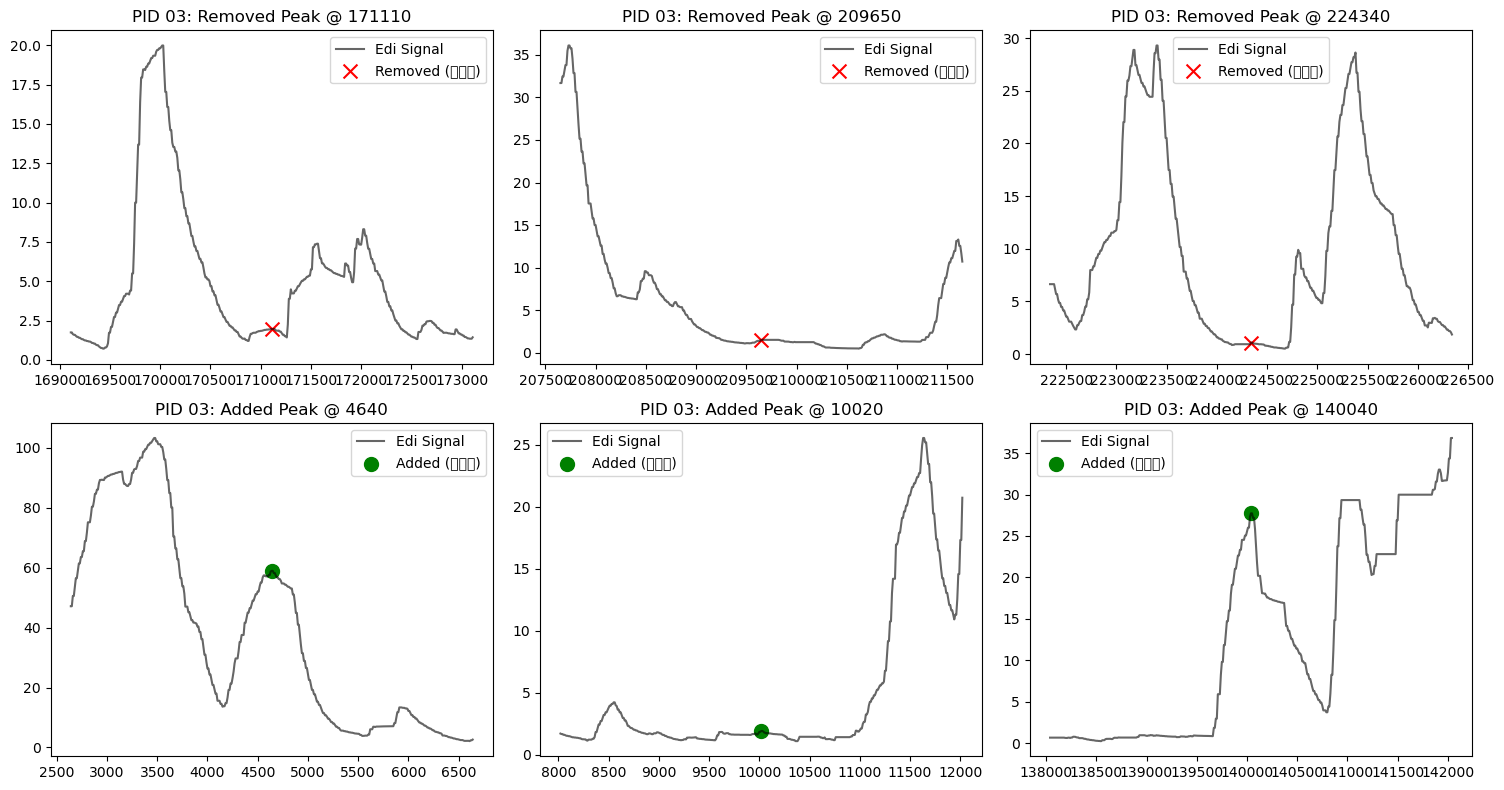

GT Peak 정제 중:   6%|▌         | 1/17 [00:07<02:00,  7.50s/it]

PID 04: 최종 Peak 개수: 2102, 제거됨: 8, 추가됨: 442


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

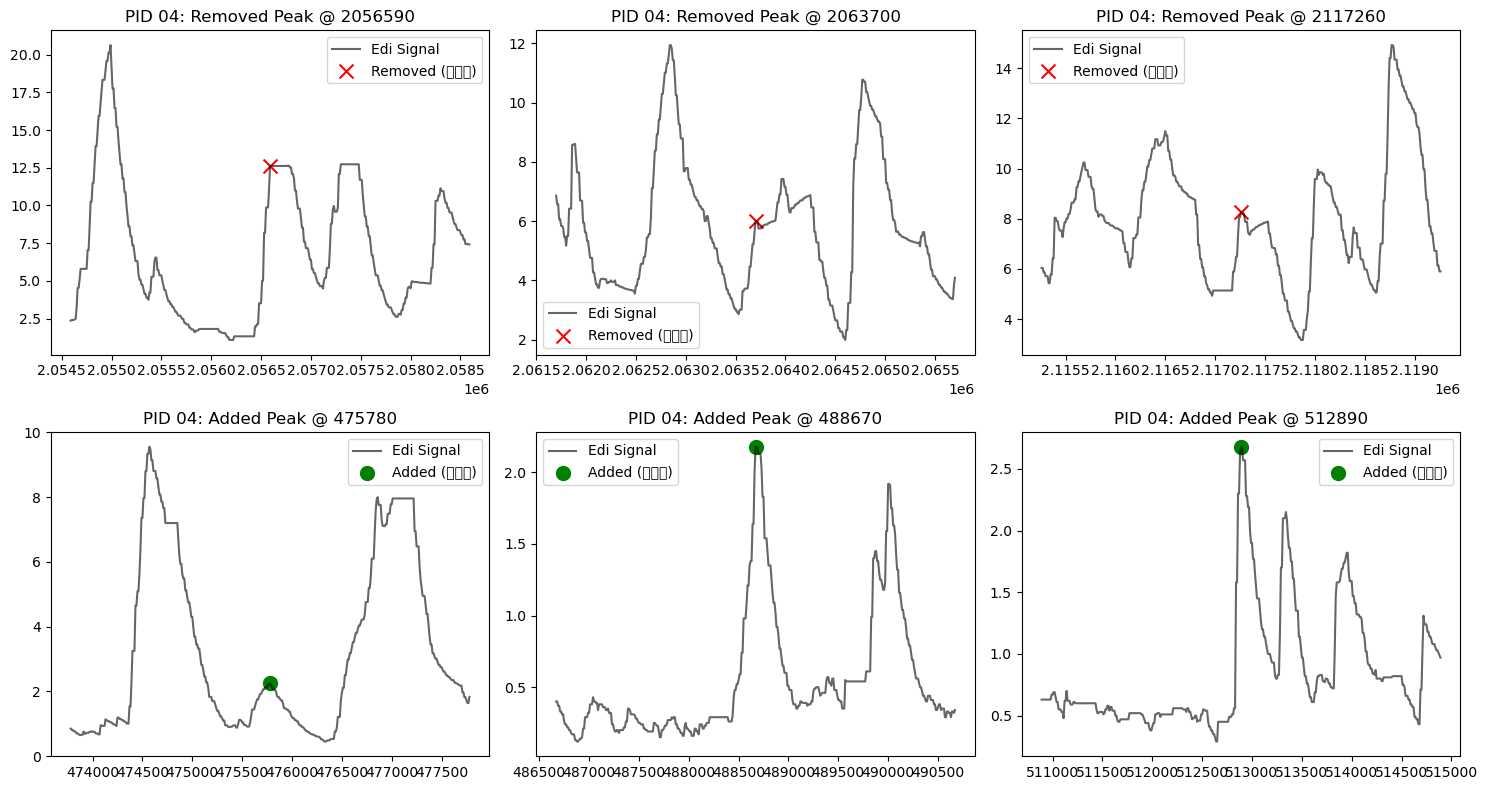

GT Peak 정제 중:  12%|█▏        | 2/17 [00:13<01:36,  6.41s/it]

PID 05: 최종 Peak 개수: 3158, 제거됨: 12, 추가됨: 167


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

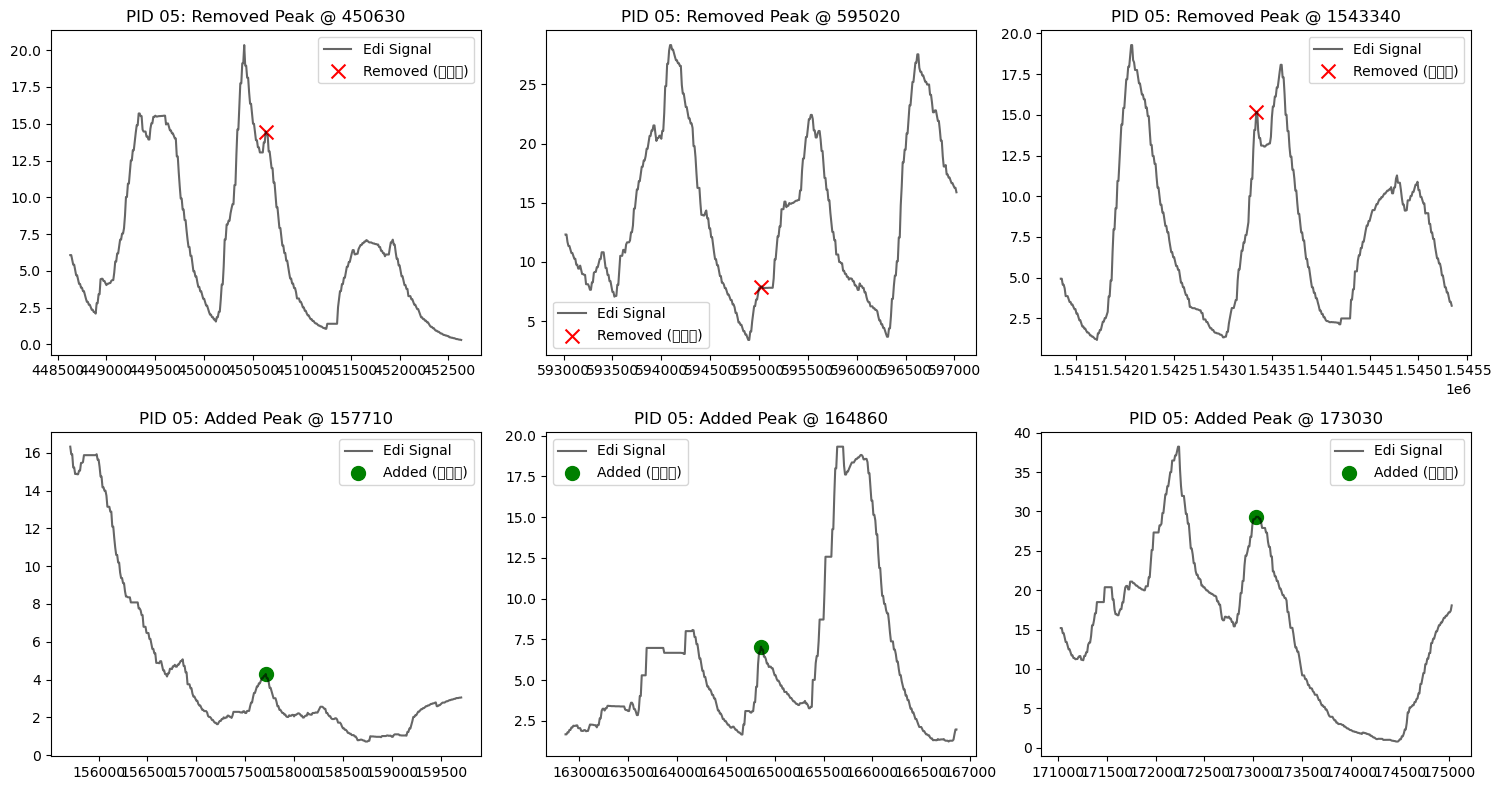

GT Peak 정제 중:  18%|█▊        | 3/17 [00:21<01:44,  7.49s/it]

PID 07: 최종 Peak 개수: 2920, 제거됨: 12, 추가됨: 397


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

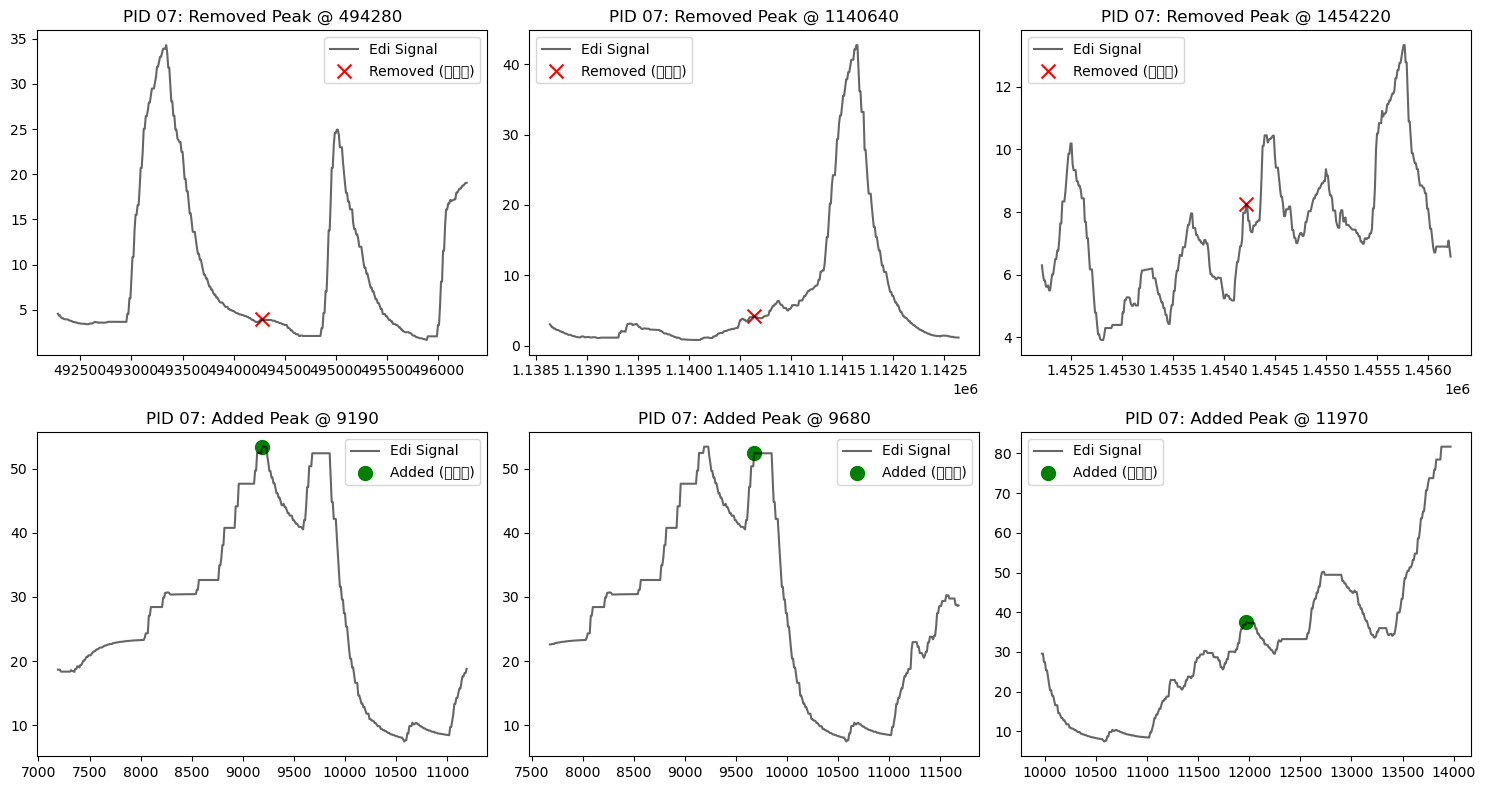

GT Peak 정제 중:  24%|██▎       | 4/17 [00:29<01:36,  7.42s/it]

PID 08: 최종 Peak 개수: 3151, 제거됨: 15, 추가됨: 266


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

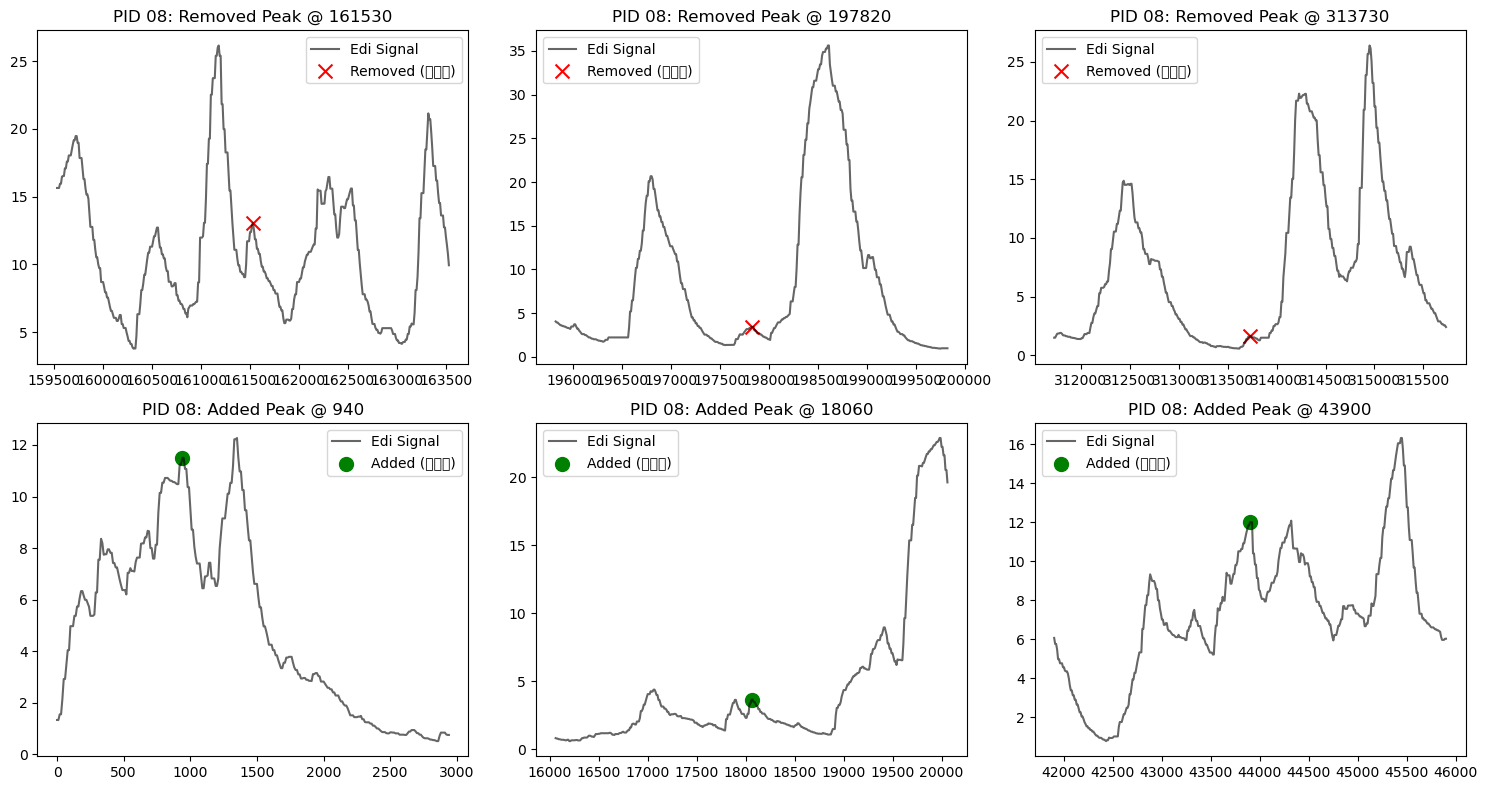

GT Peak 정제 중:  29%|██▉       | 5/17 [00:36<01:29,  7.47s/it]

PID 09: 최종 Peak 개수: 2950, 제거됨: 7, 추가됨: 82


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

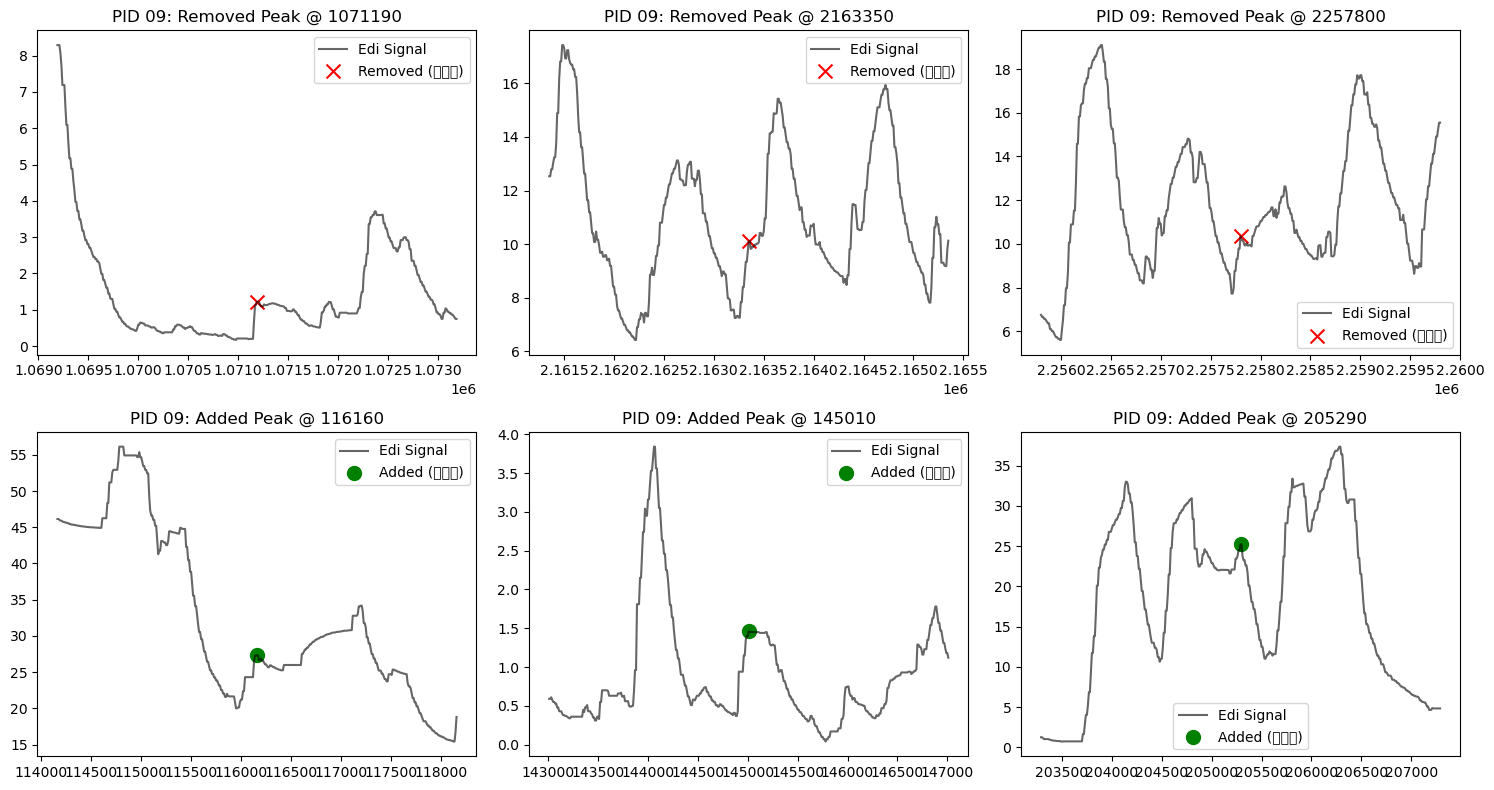

GT Peak 정제 중:  35%|███▌      | 6/17 [00:42<01:14,  6.81s/it]

PID 10: 최종 Peak 개수: 2089, 제거됨: 16, 추가됨: 20


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

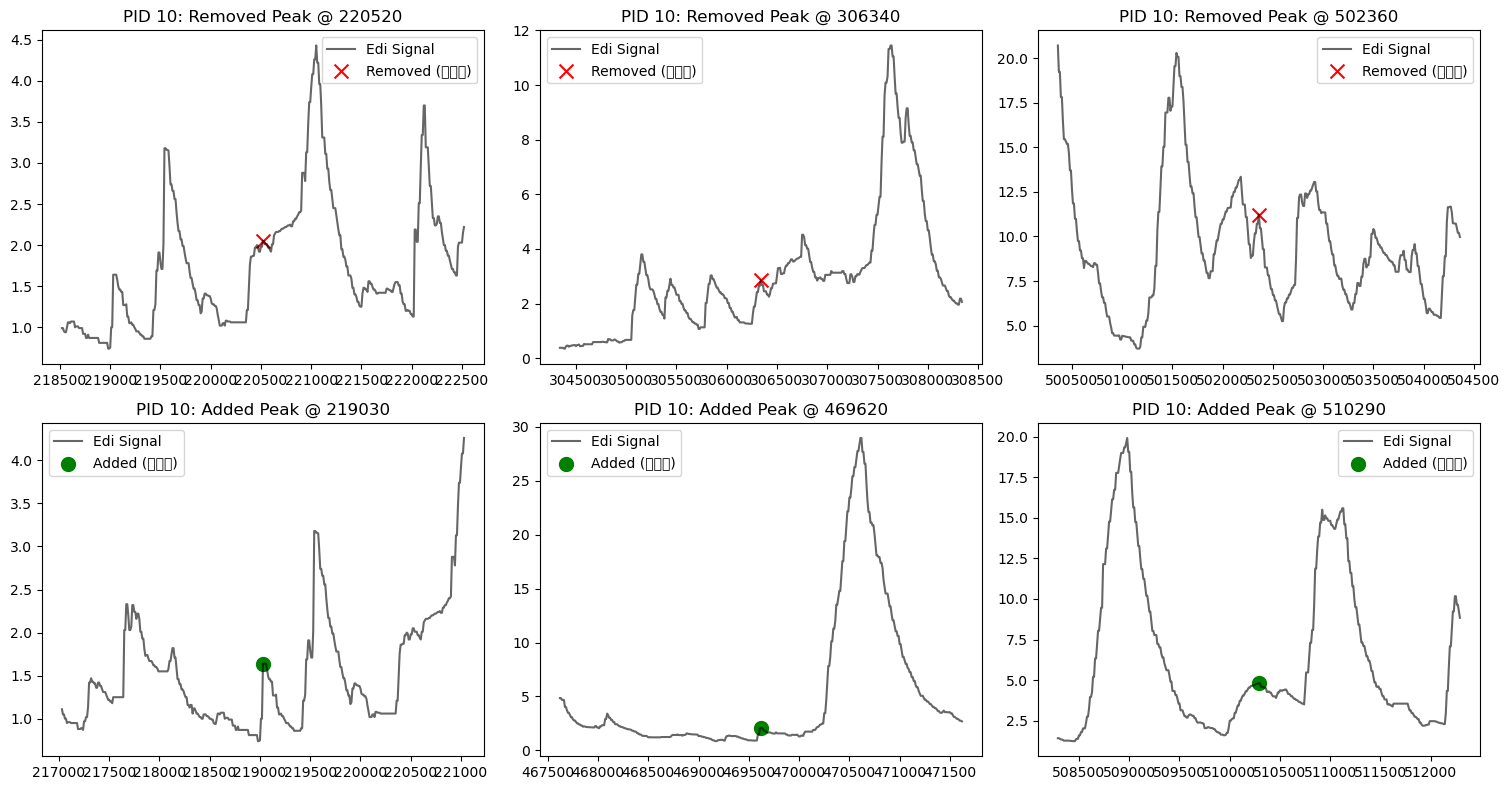

GT Peak 정제 중:  41%|████      | 7/17 [00:50<01:11,  7.12s/it]

PID 11: 최종 Peak 개수: 2219, 제거됨: 8, 추가됨: 62


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

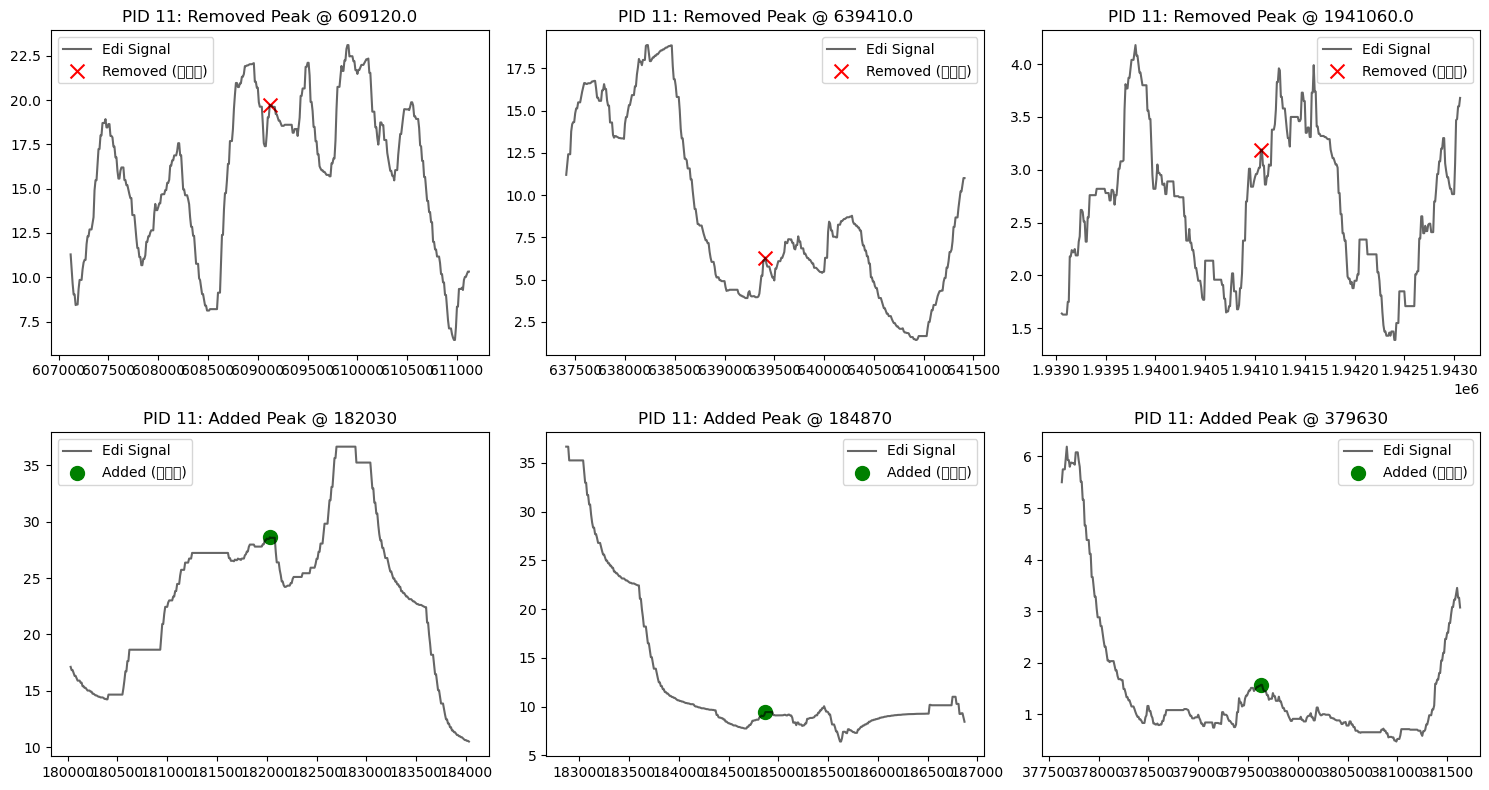

GT Peak 정제 중:  47%|████▋     | 8/17 [00:57<01:04,  7.12s/it]

PID 12: 최종 Peak 개수: 1780, 제거됨: 148, 추가됨: 68


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

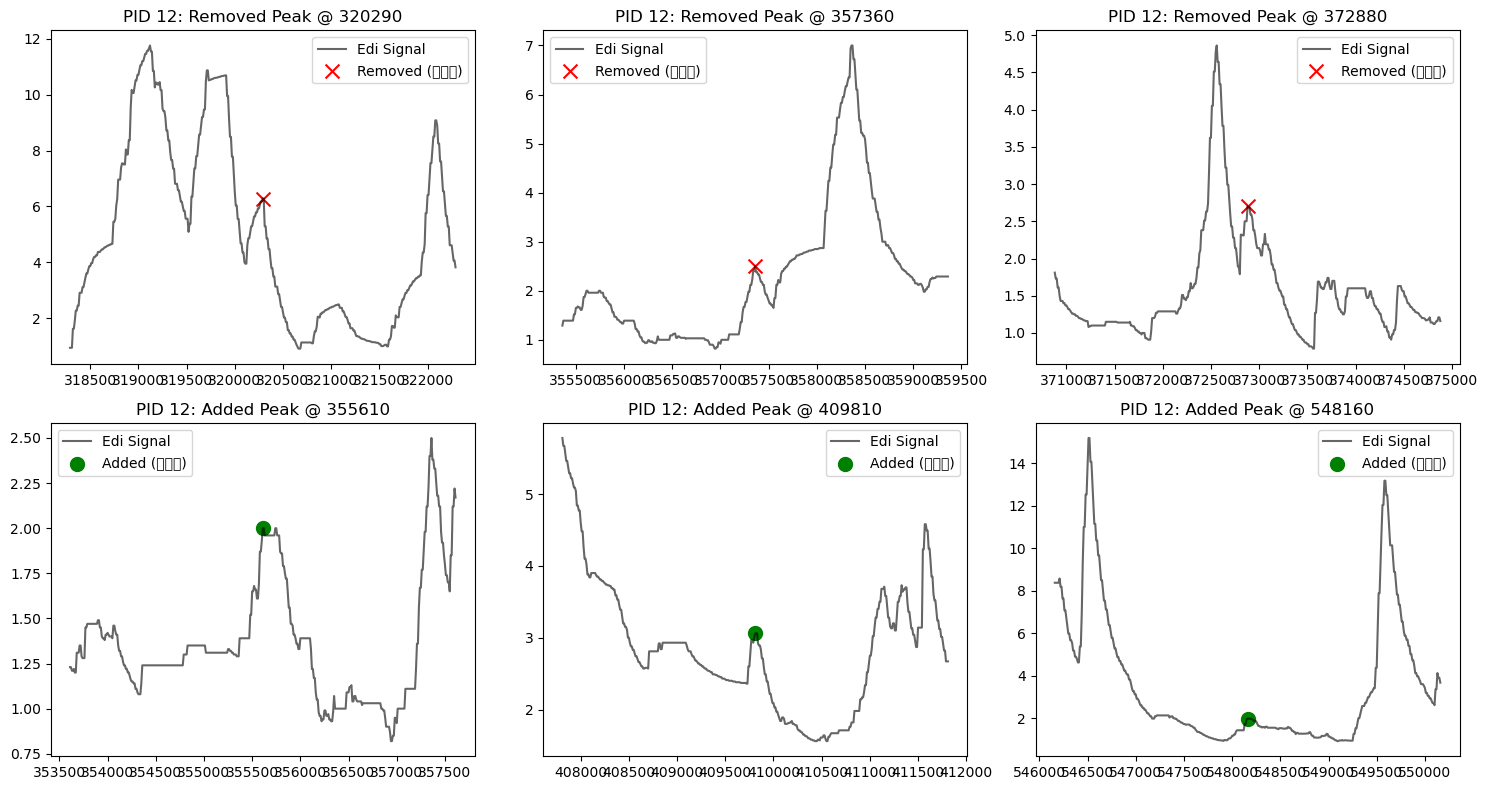

GT Peak 정제 중:  53%|█████▎    | 9/17 [01:05<00:59,  7.41s/it]

PID 13: 최종 Peak 개수: 2592, 제거됨: 124, 추가됨: 12


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

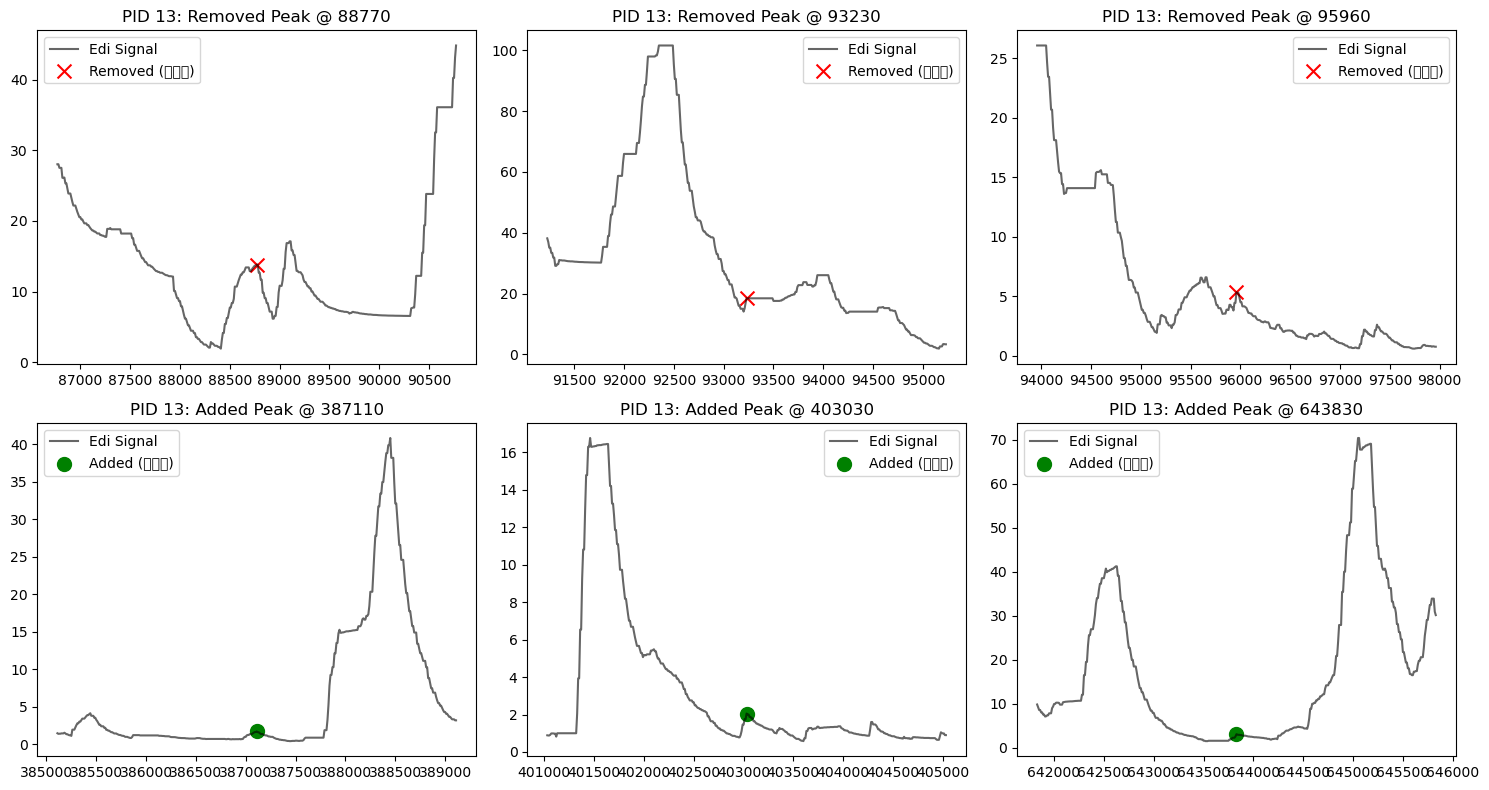

GT Peak 정제 중:  59%|█████▉    | 10/17 [01:14<00:55,  7.96s/it]

PID 14: 최종 Peak 개수: 2924, 제거됨: 12, 추가됨: 120


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

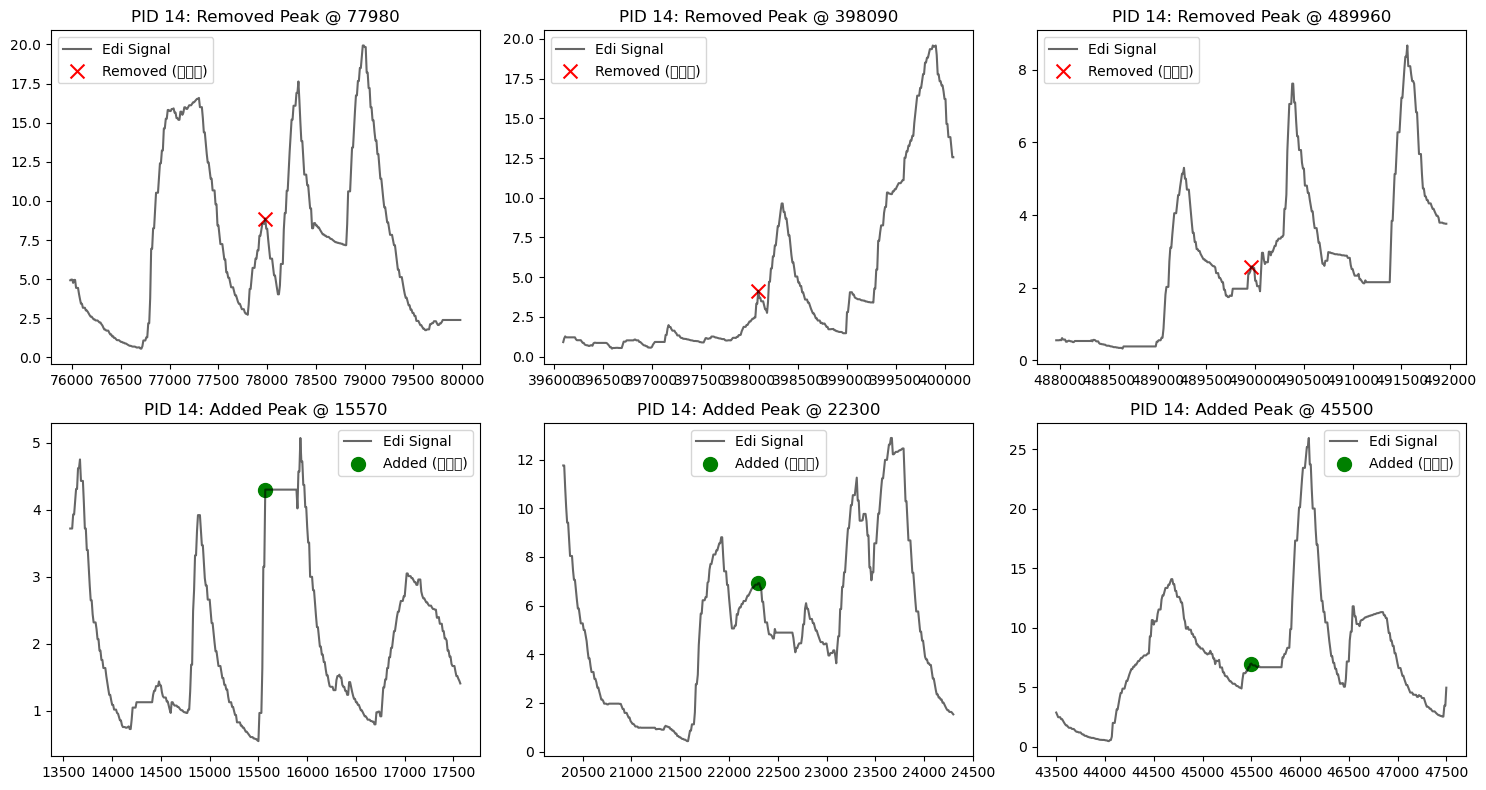

GT Peak 정제 중:  65%|██████▍   | 11/17 [01:22<00:47,  7.84s/it]

PID 15: 최종 Peak 개수: 2244, 제거됨: 6, 추가됨: 58


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

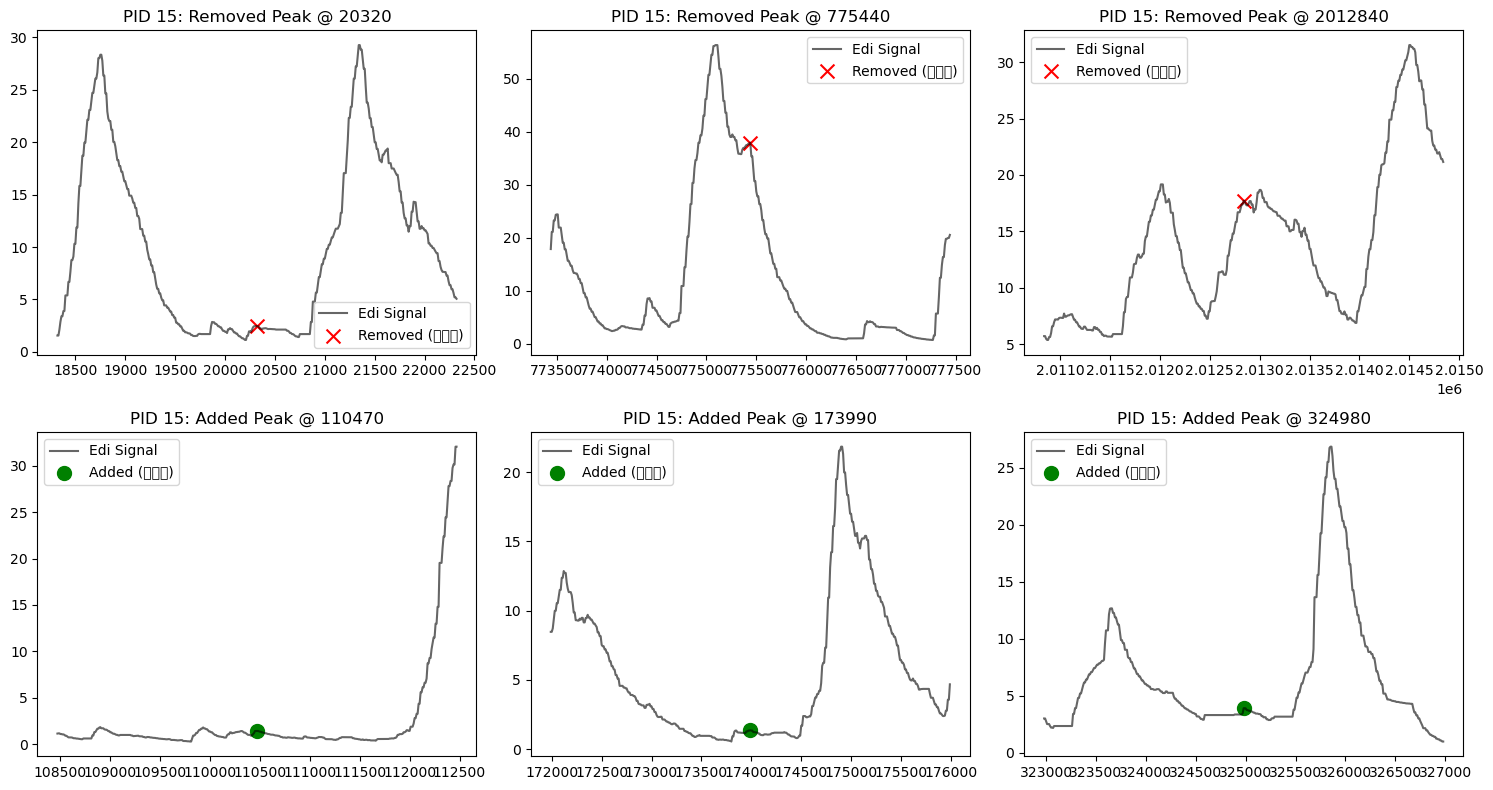

GT Peak 정제 중:  71%|███████   | 12/17 [01:29<00:38,  7.65s/it]

PID 16: 최종 Peak 개수: 2360, 제거됨: 5, 추가됨: 79


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

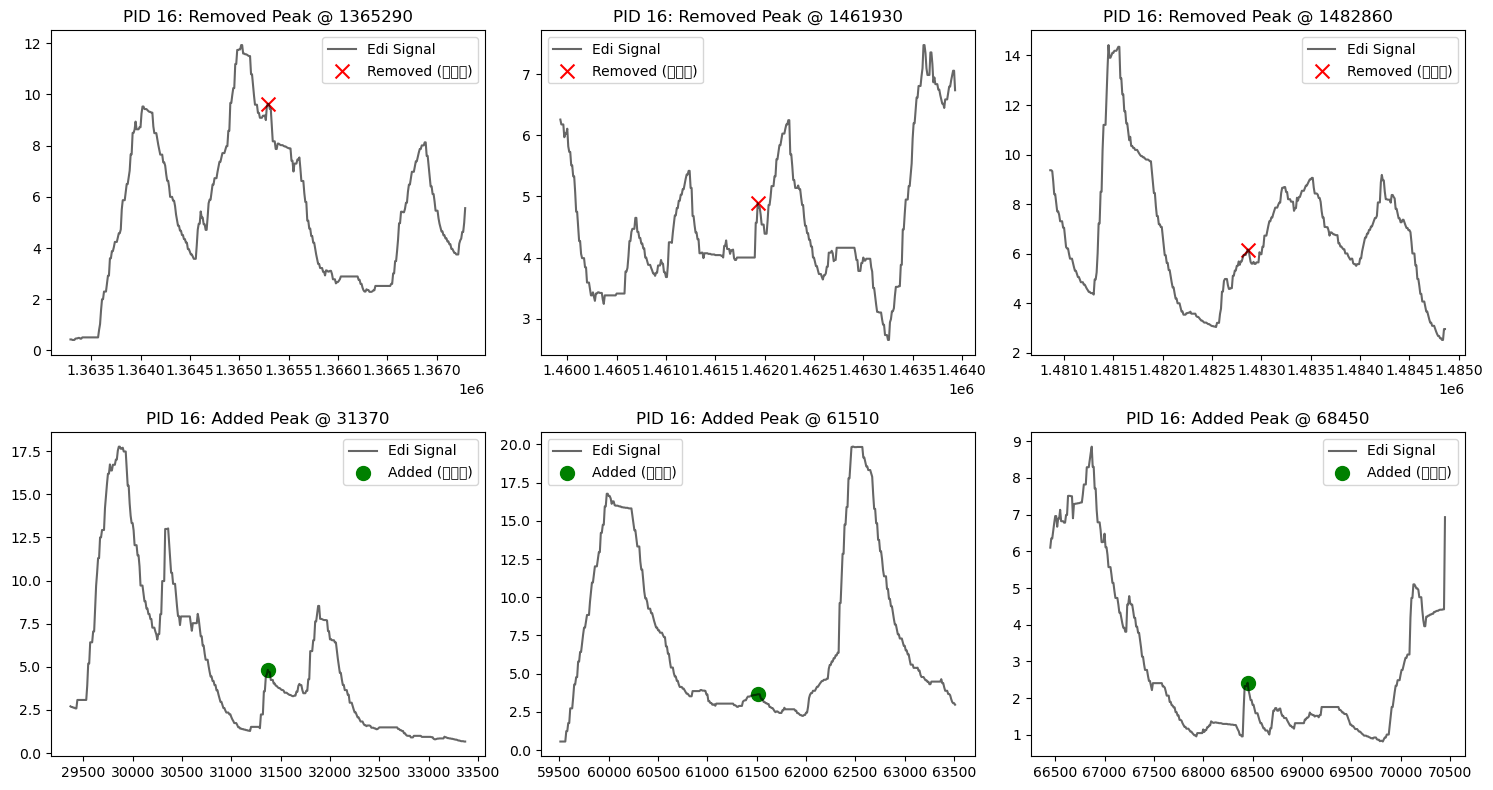

GT Peak 정제 중:  76%|███████▋  | 13/17 [01:36<00:30,  7.67s/it]

PID 17: 최종 Peak 개수: 3721, 제거됨: 15, 추가됨: 160


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

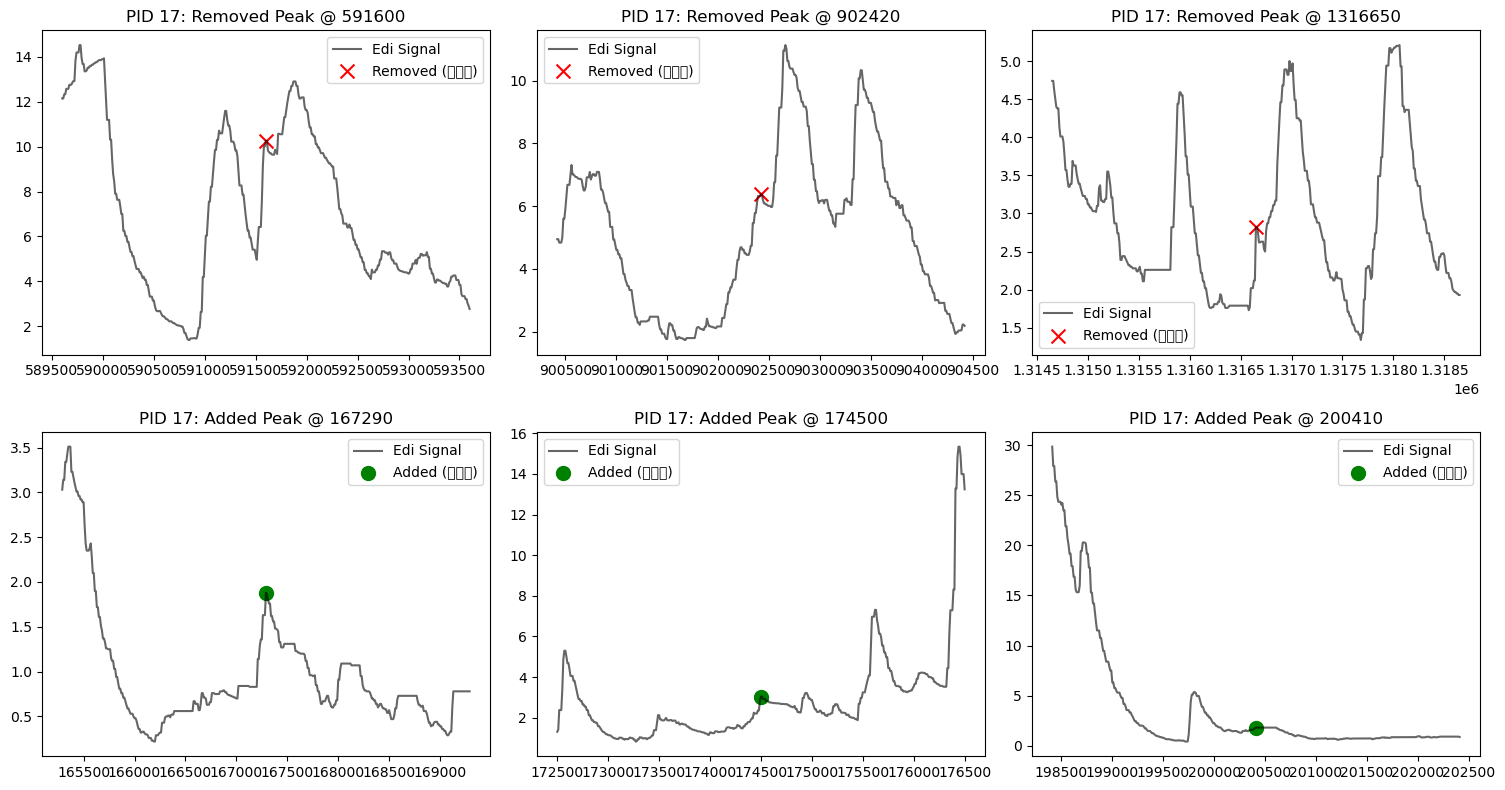

GT Peak 정제 중:  82%|████████▏ | 14/17 [01:42<00:21,  7.11s/it]

PID 18: 최종 Peak 개수: 2345, 제거됨: 39, 추가됨: 65


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

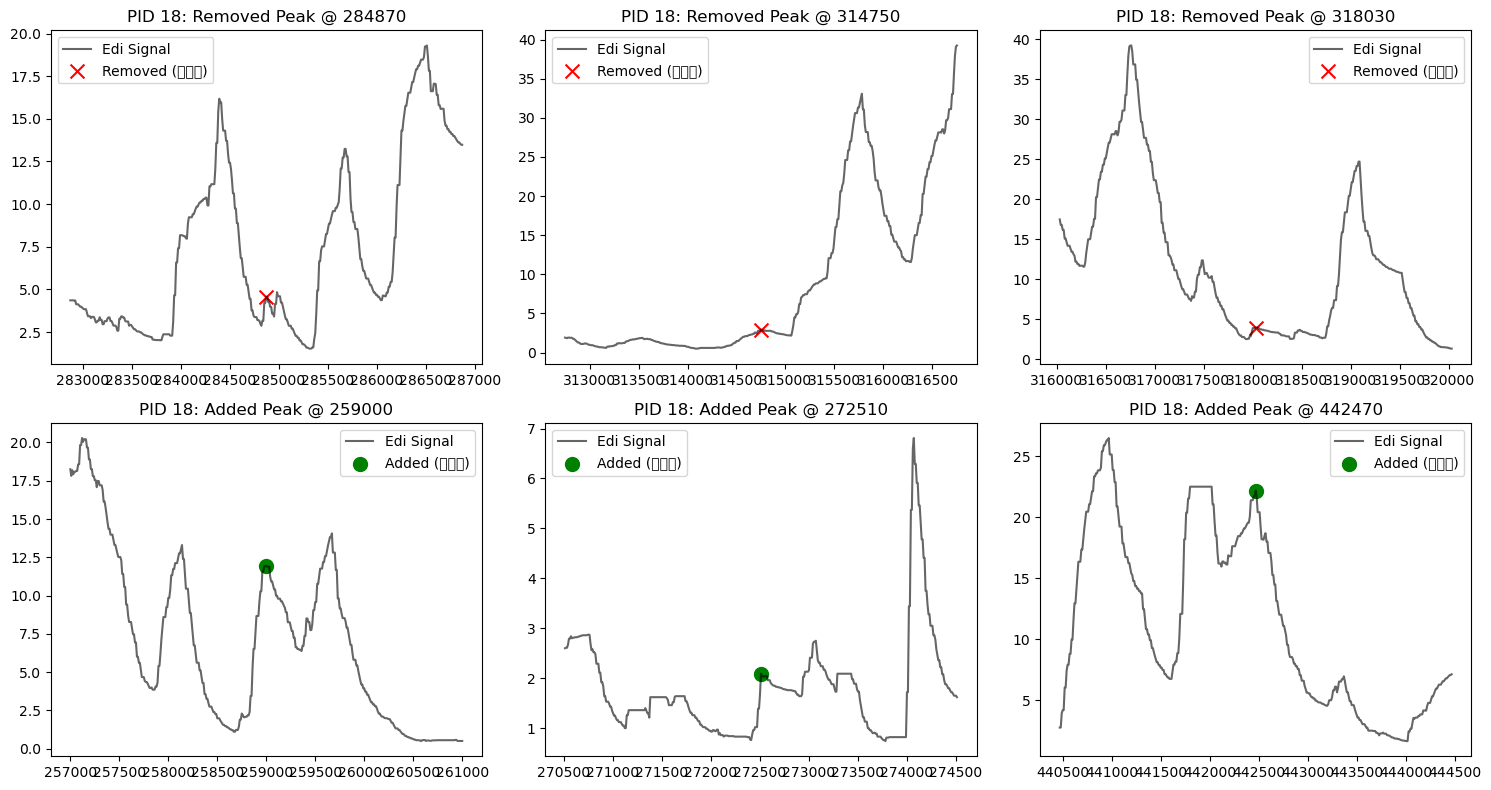

GT Peak 정제 중:  88%|████████▊ | 15/17 [01:47<00:13,  6.54s/it]

PID 19: 최종 Peak 개수: 3112, 제거됨: 26, 추가됨: 288


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

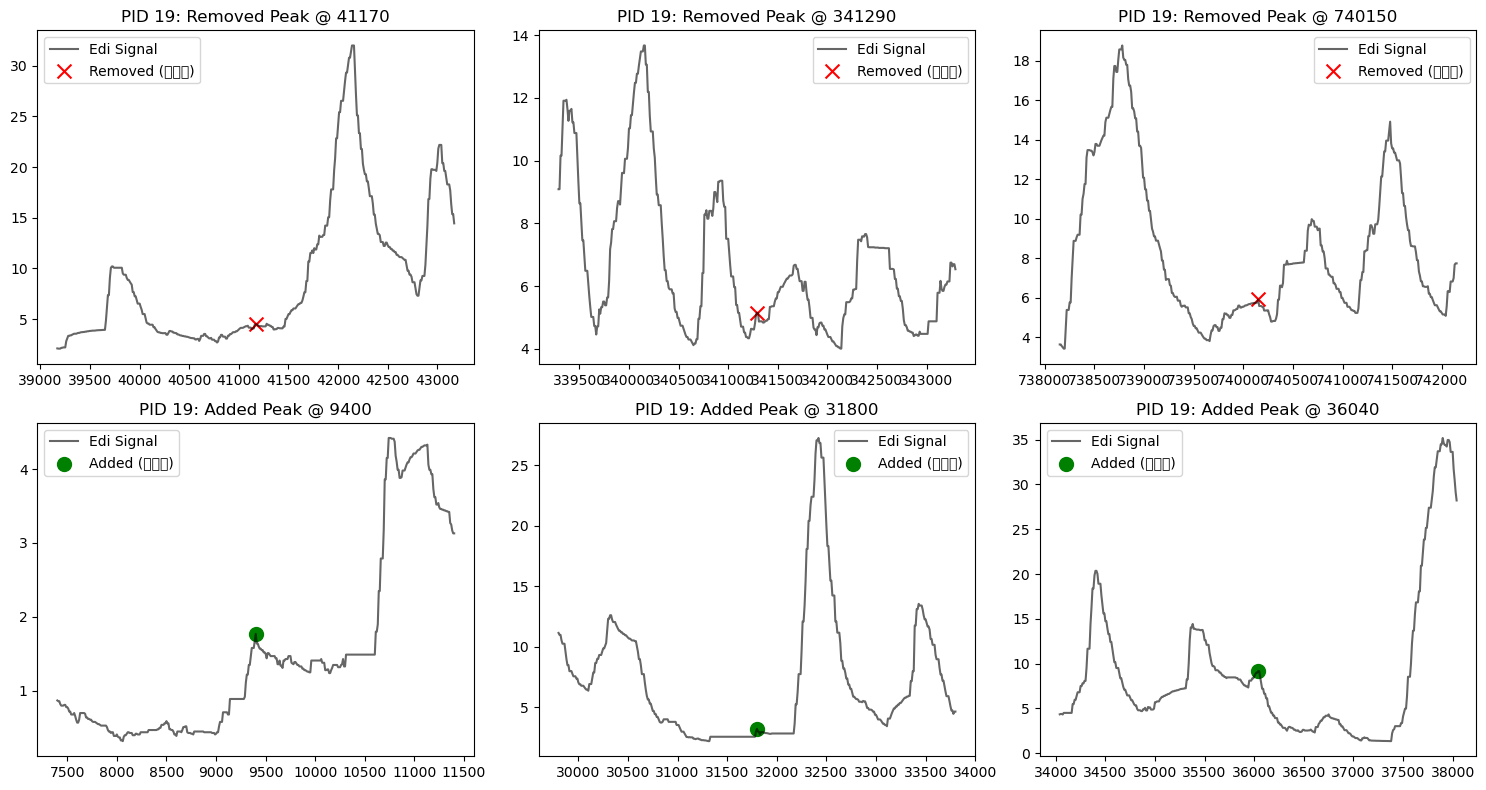

GT Peak 정제 중:  94%|█████████▍| 16/17 [01:53<00:06,  6.19s/it]

PID 20: 최종 Peak 개수: 2383, 제거됨: 36, 추가됨: 18


/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 46120 (\N{HANGUL SYLLABLE DOEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2767561/2545425987.py:90: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/cjoh/miniconda3/envs/nava_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/cjoh/miniconda3/envs/nava_env/lib/pyth

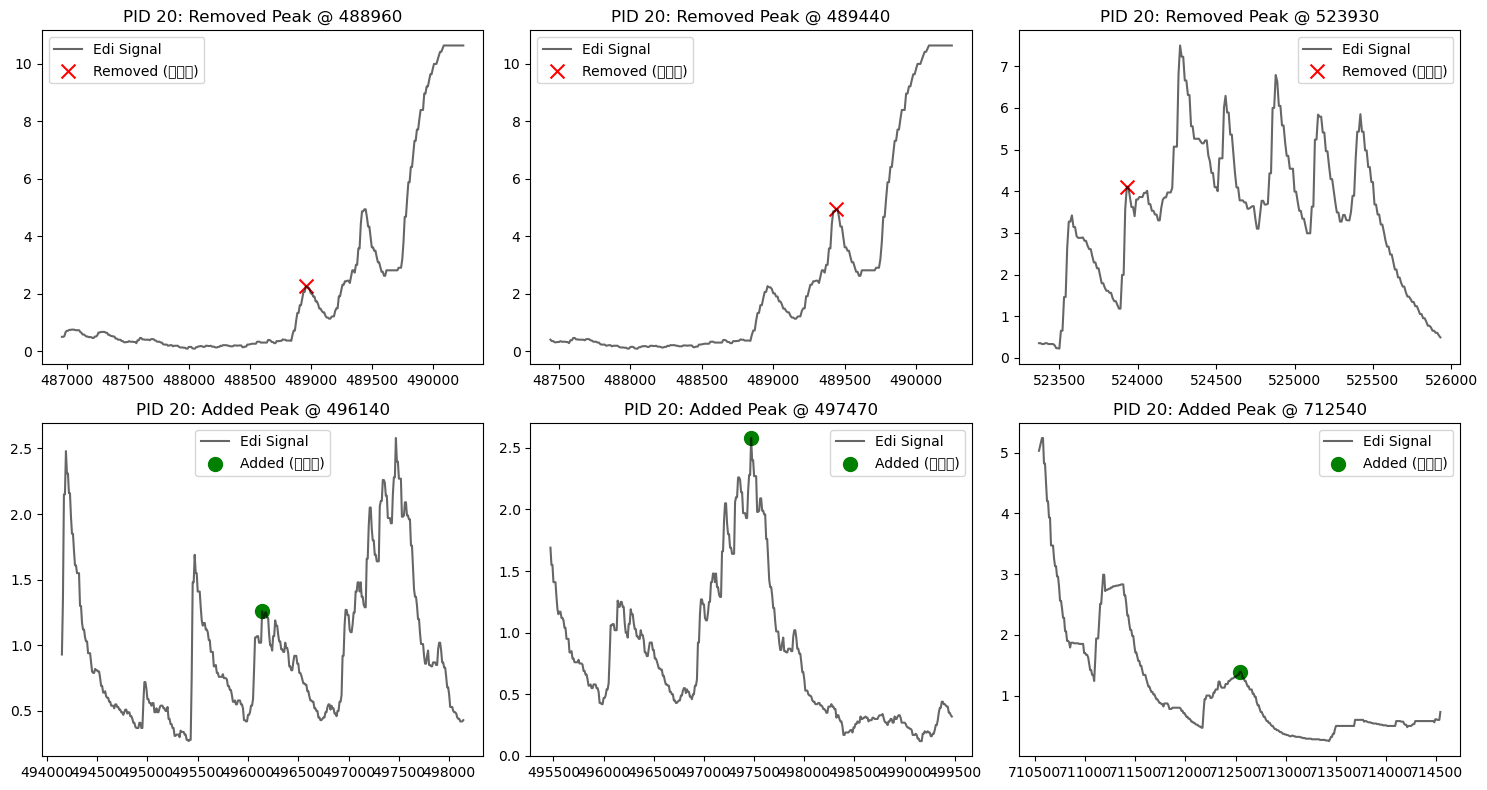

GT Peak 정제 중: 100%|██████████| 17/17 [01:58<00:00,  6.98s/it]


In [8]:
# 단계 2 실행
for pid in tqdm(PIDS, desc="GT Peak 정제 중"):
    res = refine_gt_peaks(pid)
    if res:
        refined, removed, added = res
        print(f"PID {pid}: 최종 Peak 개수: {len(refined)}, 제거됨: {len(removed)}, 추가됨: {len(added)}")
        
        # 변경사항이 있으면 예시 그래프 출력
        if removed or added:
            plot_refinement_examples(pid, removed, added)

## 단계 3: YOLO 학습 데이터 생성 (Generate YOLO Data)
YOLO 모델 학습을 위한 이미지와 라벨 파일을 생성합니다.

- **Window Size**: 2000 (20초)
- **Stride**: 1000 (10초)
- **Output**: `3_YOLO_Data/win{W}_stride{S}/{pid}/images` 및 `labels` 폴더에 저장됩니다.

**생성 로직**:
1. **이미지 (Images)**: Edi 신호를 Plot하여 축(Axis) 없이 저장합니다. `Padding=2`를 적용하여 Y축 범위를 조정합니다.
2. **라벨 (Labels)**: 해당 윈도우 내의 Peak 위치를 정규화(0~1)된 좌표로 변환하여 저장합니다. (Class ID, x_center, y_center, width, height)

In [14]:
def plot_signal_clean(data, timestamps, save_img_path, figsize=(12, 4), dpi=100, padding=2):
    """YOLO 학습용 이미지를 생성합니다. (축 없음, 흰 배경)"""
    if data.empty: return None

    # Y축 범위 설정
    data_min, data_max = data.min(), data.max()
    y_min_plot, y_max_plot = data_min - padding, data_max + padding
    ts_min, ts_max = timestamps.iloc[0], timestamps.iloc[-1]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.plot(timestamps, data, color="black", linewidth=1.5)
    ax.set_xlim(ts_min, ts_max)
    ax.set_ylim(y_min_plot, y_max_plot)

    ax.set_axis_off()
    plt.tight_layout(pad=0)
    plt.savefig(save_img_path, bbox_inches='tight', pad_inches=0, dpi=dpi, facecolor='white')
    plt.close()

    return {
        'ts_min': ts_min, 'ts_max': ts_max,
        'y_min': y_min_plot, 'y_max': y_max_plot
    }

def create_yolo_labels(window_peaks, meta):
    """윈도우 내의 Peak 좌표를 YOLO 형식(정규화된 좌표)으로 변환합니다."""
    BOX_WIDTH_RATIO = 0.01
    BOX_HEIGHT_RATIO = 0.05
    CLASS_ID = 0 # Peak 클래스 ID는 0
    
    labels = []
    ts_range = meta['ts_max'] - meta['ts_min']
    y_range = meta['y_max'] - meta['y_min']

    for ts, amp in window_peaks:
        if ts_range <= 0 or y_range <= 0: continue
        
        x_center = (ts - meta['ts_min']) / ts_range
        y_center = 1.0 - (amp - meta['y_min']) / y_range

        x_center = max(0.001, min(0.999, x_center))
        y_center = max(0.001, min(0.999, y_center))

        labels.append(f'{CLASS_ID} {x_center:.6f} {y_center:.6f} {BOX_WIDTH_RATIO:.6f} {BOX_HEIGHT_RATIO:.6f}')
    return labels

def analyze_inter_peak_intervals(df_gt, pid):
    """Peak 간 간격을 분석하고 히스토그램을 그립니다 (Mean 표시)."""
    df_gt = df_gt.sort_values('timestamp')
    # ms -> sec 변환
    intervals_sec = df_gt['timestamp'].diff().dropna() / 1000.0
    
    mean_val = intervals_sec.mean()
    max_val = intervals_sec.max()
    min_val = intervals_sec.min()
    
    print(f"\n[PID {pid}] Peak 간격 분석:")
    print(f"  - 평균: {mean_val:.2f} sec")
    print(f"  - 최대: {max_val:.2f} sec")
    print(f"  - 최소: {min_val:.2f} sec")
    
    # 히스토그램 그리기 (Always)
    plt.figure(figsize=(10, 4))
    plt.hist(intervals_sec, bins=50, color='skyblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_val:.2f}s')
    
    plt.title(f"PID {pid}: Inter-Peak Interval Distribution\nMean: {mean_val:.2f} sec")
    plt.xlabel("Interval (sec)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 5초 이상 간격 경고
    long_gaps = intervals_sec[intervals_sec > 5.0]
    if not long_gaps.empty:
        print(f"  [!] 5초 이상 간격 {len(long_gaps)}개 발견 (Max: {long_gaps.max():.2f}s)")


In [15]:
def plot_example_with_bboxes(img_path, labels_path, pid, fname):
    """저장된 이미지를 불러와서 Bbox를 그려 제대로 만들어졌는지 확인하는 함수"""
    if not os.path.exists(img_path) or not os.path.exists(labels_path):
        print(f"[Error] {fname}: 파일이 존재하지 않습니다.")
        return

    # 이미지 로드
    img = Image.open(img_path)
    img_w, img_h = img.size
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(img)
    
    # 라벨 로드 및 Bbox 그리기
    with open(labels_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5: continue
        
        cls_id = int(parts[0])
        x_center_n = float(parts[1])
        y_center_n = float(parts[2])
        width_n = float(parts[3])
        height_n = float(parts[4])
        
        # 정규화된 좌표 -> 픽셀 좌표 변환
        box_w = width_n * img_w
        box_h = height_n * img_h
        box_x = (x_center_n * img_w) - (box_w / 2)
        box_y = (y_center_n * img_h) - (box_h / 2)
        
        rect = patches.Rectangle((box_x, box_y), box_w, box_h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        
    ax.set_axis_off()
    ax.set_title(f"[Check] PID {pid} - {fname} (Loaded Image)")
    plt.show()


In [ ]:
def generate_yolo_data(pid, window_size=2000, stride=1000):
    """환자별로 Sliding Window를 수행하여 YOLO 데이터셋을 생성합니다."""
    
    # 1. 파일 로드
    raw_file = os.path.join(REFINED_RAW_DIR, f"{pid}.xlsx")
    gt_file = os.path.join(REFINED_PEAKS_DIR, f"refined_peaks_patient_{pid}.xlsx")
    
    if not os.path.exists(raw_file) or not os.path.exists(gt_file):
        print(f"PID {pid}: 필요한 파일이 없어 건너뜁니다.")
        return
        
    df_raw = pd.read_excel(raw_file)
    df_gt = pd.read_excel(gt_file)
    
    # 2. [Trimming] 데이터 범위 맞추기 (Intersection)
    # GT와 Raw가 모두 존재하는 교집합 구간만 사용합니다.
    raw_min, raw_max = df_raw['timestamp'].min(), df_raw['timestamp'].max()
    gt_min, gt_max = df_gt['timestamp'].min(), df_gt['timestamp'].max()
    
    start_ts = max(raw_min, gt_min)
    end_ts = min(raw_max, gt_max)
    
    print(f"\n[PID {pid} 범위 정보]")
    print(f"  - Raw 범위: {raw_min} ~ {raw_max}")
    print(f"  - GT 범위 : {gt_min} ~ {gt_max}")
    print(f"  - 적용 구간 (Intersection): {start_ts} ~ {end_ts}")
    
    # Raw 데이터 자르기
    df_raw = df_raw[(df_raw['timestamp'] >= start_ts) & (df_raw['timestamp'] <= end_ts)].reset_index(drop=True)
    
    if df_raw.empty:
        print(f"[Error] PID {pid}: 유효한 겹치는 구간이 없습니다!")
        return
    
    # 3. Inter-Peak Interval 분석
    analyze_inter_peak_intervals(df_gt, pid) # 그냥 확인용
    
    # GT와 Raw 데이터 병합
    df_peaks_aligned = pd.merge(df_gt, df_raw[['timestamp', 'edi']], on='timestamp', how='left')
    df_peaks_aligned.dropna(subset=['edi'], inplace=True)
    
    # 저장 경로
    base_out = os.path.join(YOLO_DATA_DIR, f"win{window_size}_stride{stride}", pid)
    img_out = os.path.join(base_out, "images")
    lbl_out = os.path.join(base_out, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)
    
    # Sliding Window
    total_pts = len(df_raw)
    num_windows = (total_pts - window_size) // stride + 1
    
    win_count = 0
    skip_count = 0
    
    # 예시 플롯을 위해 몇 개만 저장
    example_plotted = 0
    
    for w_idx in tqdm(range(num_windows), desc=f"Processing {pid}", leave=False):
        start_idx = w_idx * stride
        end_idx = start_idx + window_size
        if end_idx > total_pts: break

        window_df = df_raw.iloc[start_idx:end_idx]

        if window_df['edi'].isna().any():
            skip_count += 1
            continue

        ts_min, ts_max = window_df['timestamp'].iloc[0], window_df['timestamp'].iloc[-1]

        # 이 윈도우에서 필요한 GT만 남긴다.
        window_peaks_df = df_peaks_aligned[(df_peaks_aligned['timestamp'] >= ts_min) & (df_peaks_aligned['timestamp'] <= ts_max)]
        window_peaks = list(zip(window_peaks_df['timestamp'], window_peaks_df['edi']))

        fname = f'p{pid}_w{w_idx:04d}'
        img_file = os.path.join(img_out, f'{fname}.png')

        meta = plot_signal_clean(window_df['edi'], window_df['timestamp'], img_file, padding=PADDING)

        if meta:
            labels = create_yolo_labels(window_peaks, meta)
            if labels:
                with open(os.path.join(lbl_out, f'{fname}.txt'), 'w') as f:
                    f.write('\n'.join(labels))
                win_count += 1
                
                # 3개의 예시 윈도우에 대해 Bbox 시각화 (초기 3개만)
                if example_plotted < 3:
                    lbl_file = os.path.join(lbl_out, f'{fname}.txt')
                    plot_example_with_bboxes(img_file, lbl_file, pid, fname)
                    example_plotted += 1
                
    print(f"PID {pid}: {win_count}개 윈도우 생성 완료. (NaN 스킵: {skip_count}개)")


YOLO 데이터 생성 시작... Window=2000, Stride=1000


YOLO 데이터 생성:   0%|          | 0/17 [00:00<?, ?it/s]


[PID 03 범위 정보]
  - Raw 범위: 20 ~ 4000010
  - GT 범위 : 3470 ~ 3420360
  - 적용 구간 (Intersection): 3470 ~ 3420360

[PID 03] Peak 간격 분석:
  - 평균: 2.00 sec
  - 최대: 11.75 sec
  - 최소: 0.24 sec


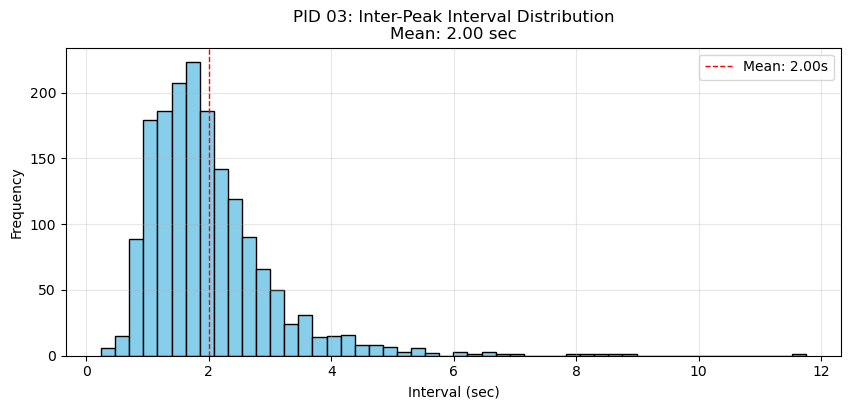

  [!] 5초 이상 간격 29개 발견 (Max: 11.75s)


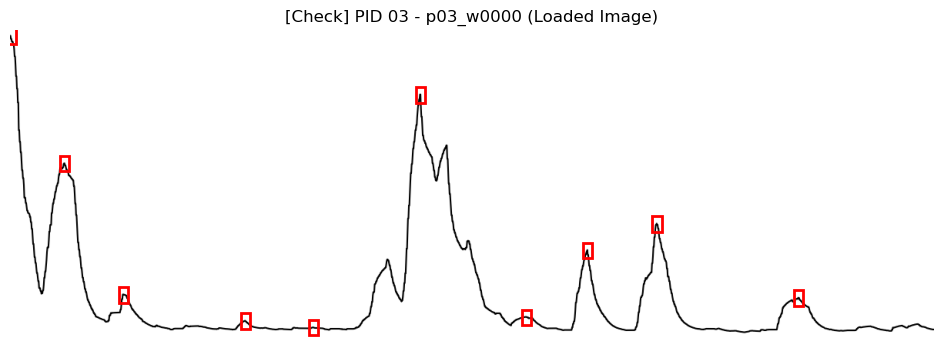

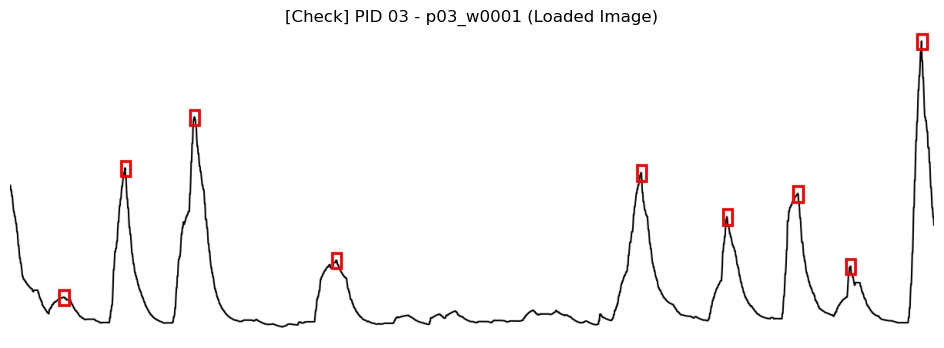

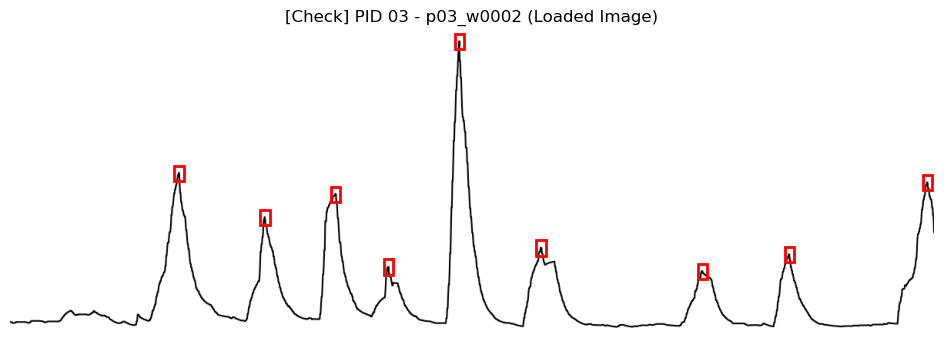

YOLO 데이터 생성:   6%|▌         | 1/17 [00:17<04:34, 17.17s/it]

PID 03: 340개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 04 범위 정보]
  - Raw 범위: 467350 ~ 3467340
  - GT 범위 : 470530 ~ 3465000
  - 적용 구간 (Intersection): 470530 ~ 3465000

[PID 04] Peak 간격 분석:
  - 평균: 1.43 sec
  - 최대: 7.34 sec
  - 최소: 0.18 sec


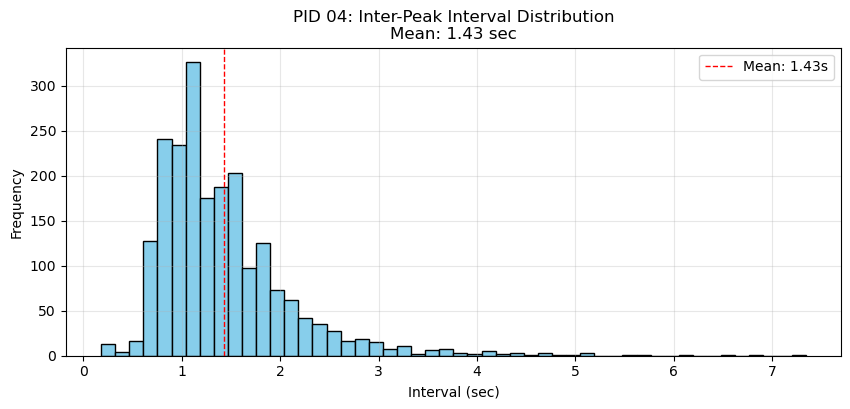

  [!] 5초 이상 간격 9개 발견 (Max: 7.34s)


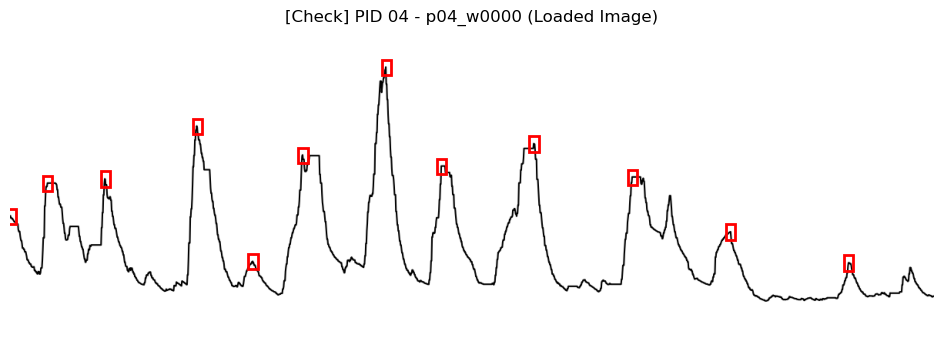

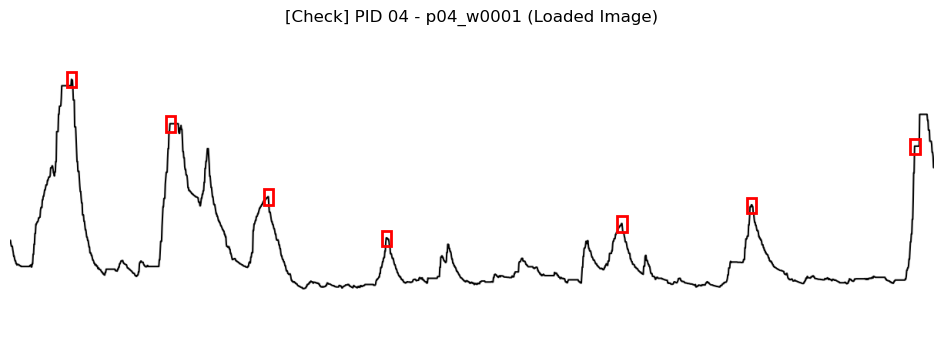

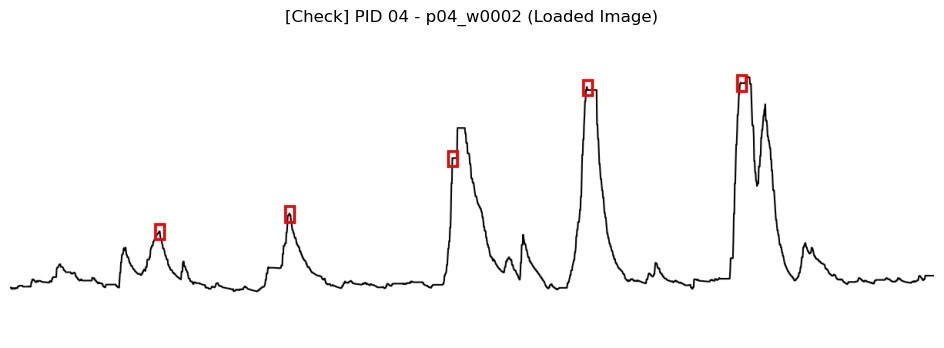

YOLO 데이터 생성:  12%|█▏        | 2/17 [00:32<03:58, 15.93s/it]

PID 04: 298개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 05 범위 정보]
  - Raw 범위: 0 ~ 4002850
  - GT 범위 : 135920 ~ 3419740
  - 적용 구간 (Intersection): 135920 ~ 3419740

[PID 05] Peak 간격 분석:
  - 평균: 1.04 sec
  - 최대: 6.48 sec
  - 최소: 0.14 sec


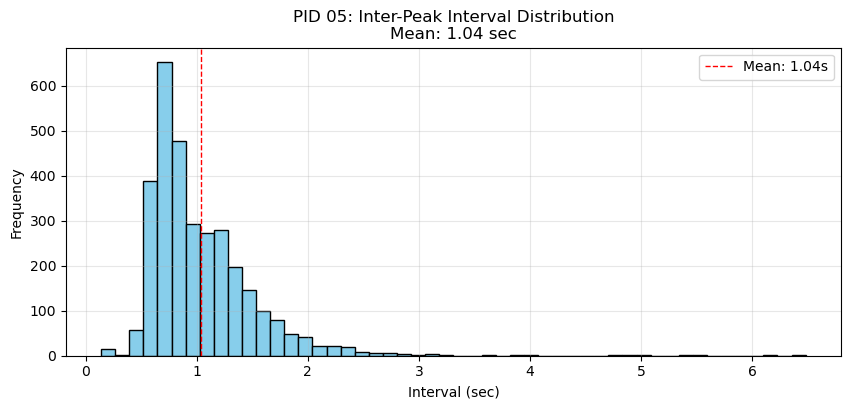

  [!] 5초 이상 간격 4개 발견 (Max: 6.48s)


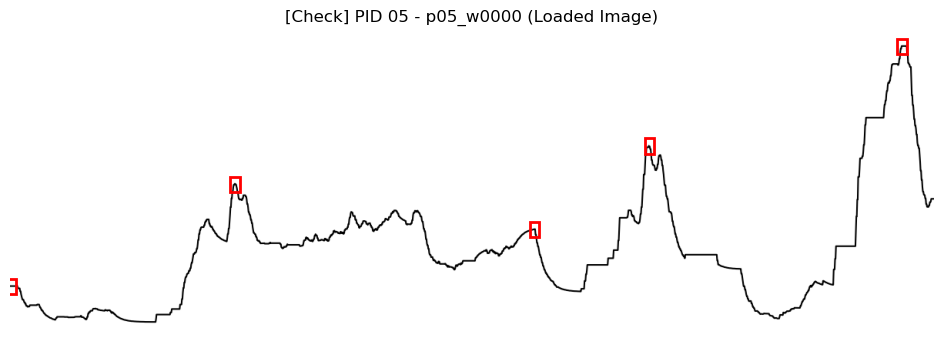

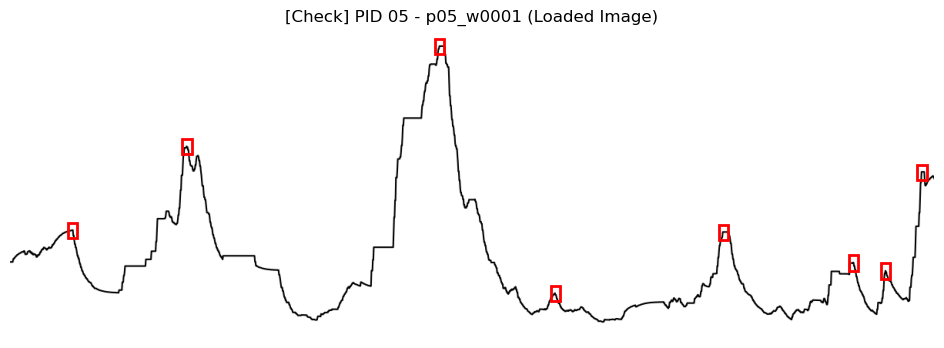

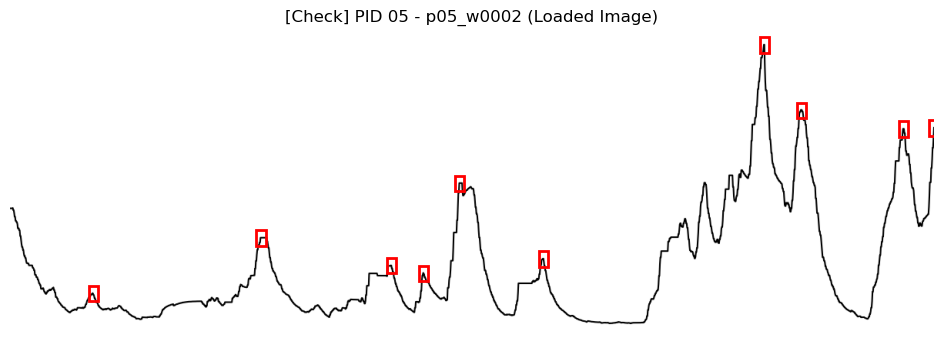

YOLO 데이터 생성:  18%|█▊        | 3/17 [00:50<03:57, 16.94s/it]

PID 05: 327개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 07 범위 정보]
  - Raw 범위: 6620 ~ 4006610
  - GT 범위 : 9190 ~ 3421820
  - 적용 구간 (Intersection): 9190 ~ 3421820

[PID 07] Peak 간격 분석:
  - 평균: 1.17 sec
  - 최대: 8.54 sec
  - 최소: 0.17 sec


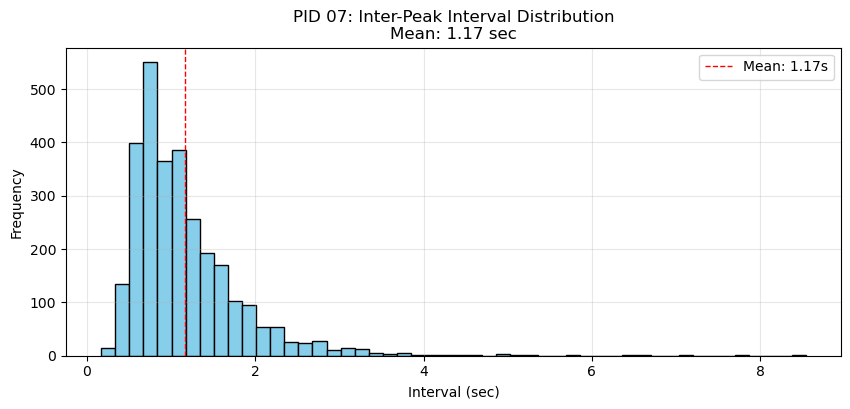

  [!] 5초 이상 간격 10개 발견 (Max: 8.54s)


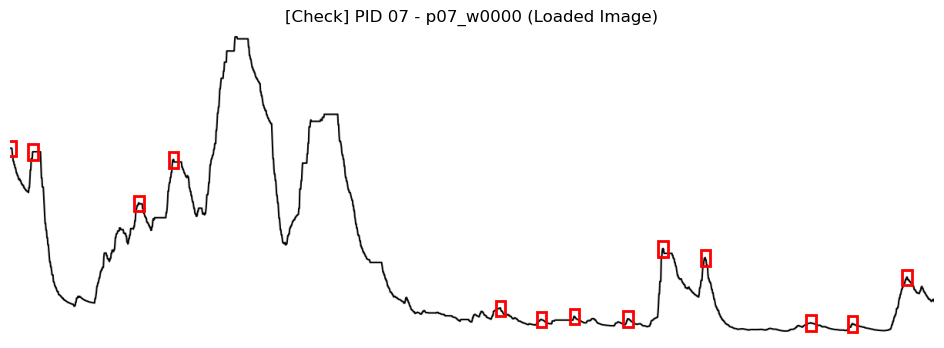

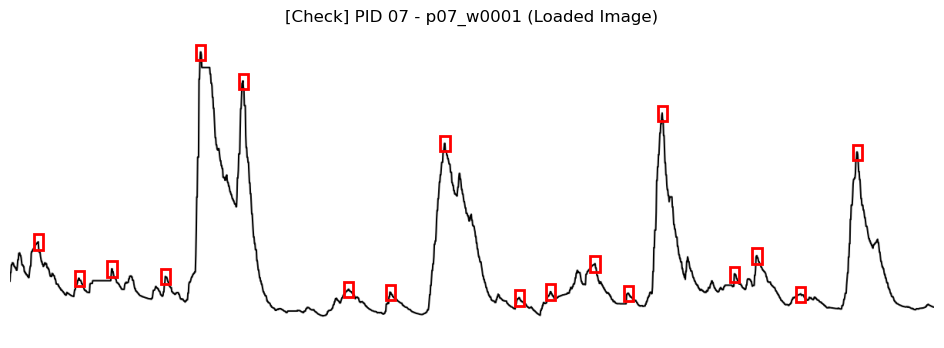

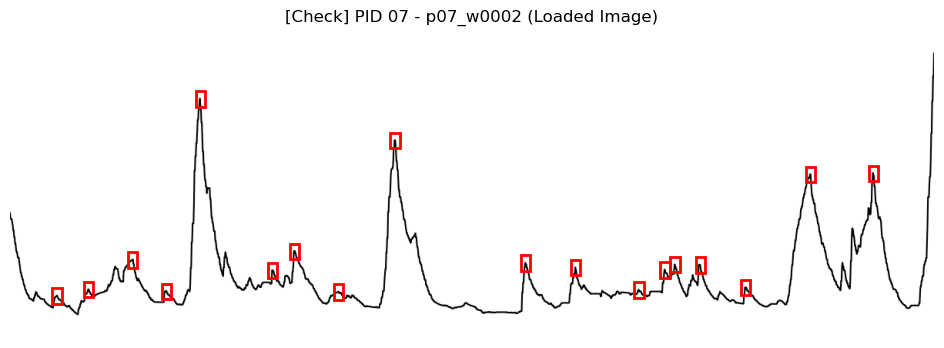

YOLO 데이터 생성:  24%|██▎       | 4/17 [01:07<03:42, 17.12s/it]

PID 07: 340개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 08 범위 정보]
  - Raw 범위: 0 ~ 4003360
  - GT 범위 : 940 ~ 3359660
  - 적용 구간 (Intersection): 940 ~ 3359660

[PID 08] Peak 간격 분석:
  - 평균: 1.07 sec
  - 최대: 10.30 sec
  - 최소: 0.14 sec


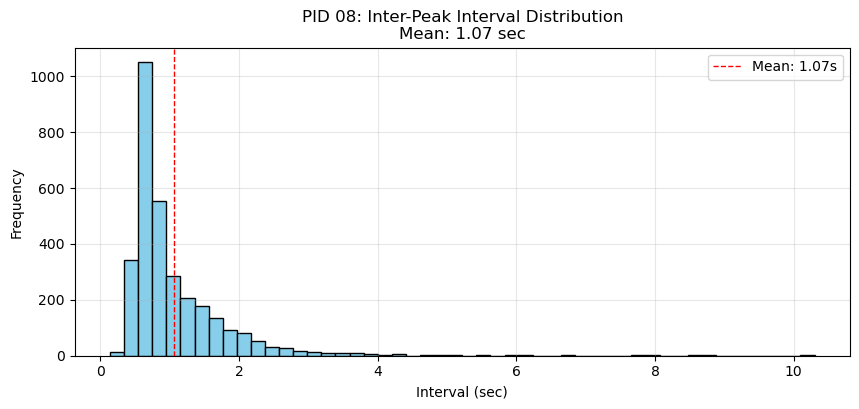

  [!] 5초 이상 간격 13개 발견 (Max: 10.30s)


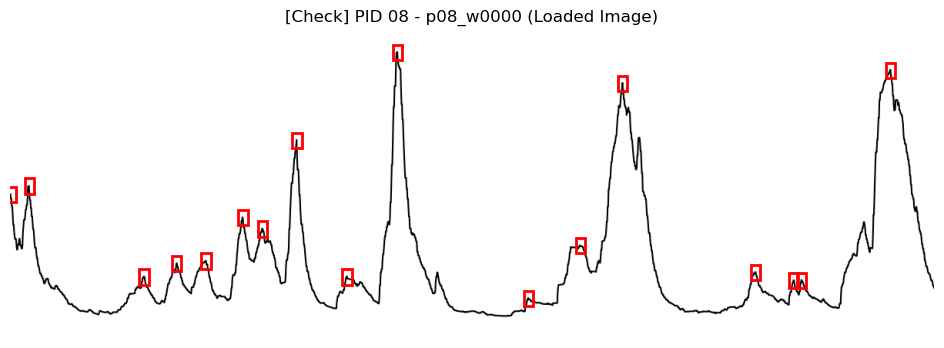

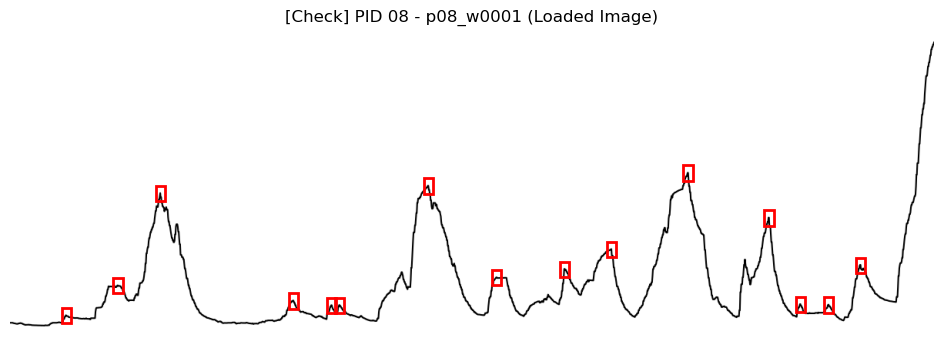

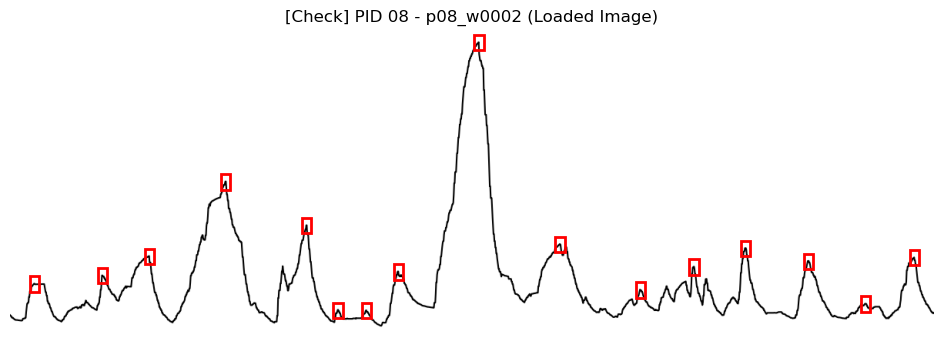

YOLO 데이터 생성:  29%|██▉       | 5/17 [01:25<03:26, 17.24s/it]

PID 08: 332개 윈도우 생성 완료. (NaN 스킵: 2개)

[PID 09 범위 정보]
  - Raw 범위: 110710 ~ 4110700
  - GT 범위 : 113460 ~ 3419140
  - 적용 구간 (Intersection): 113460 ~ 3419140

[PID 09] Peak 간격 분석:
  - 평균: 1.12 sec
  - 최대: 7.17 sec
  - 최소: 0.19 sec


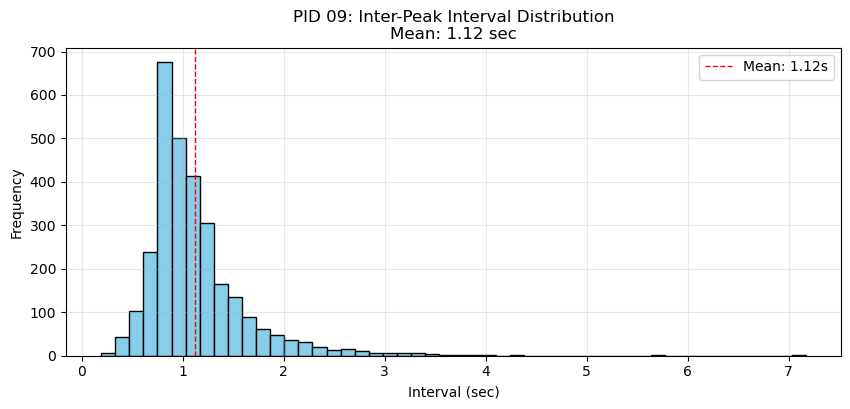

  [!] 5초 이상 간격 2개 발견 (Max: 7.17s)


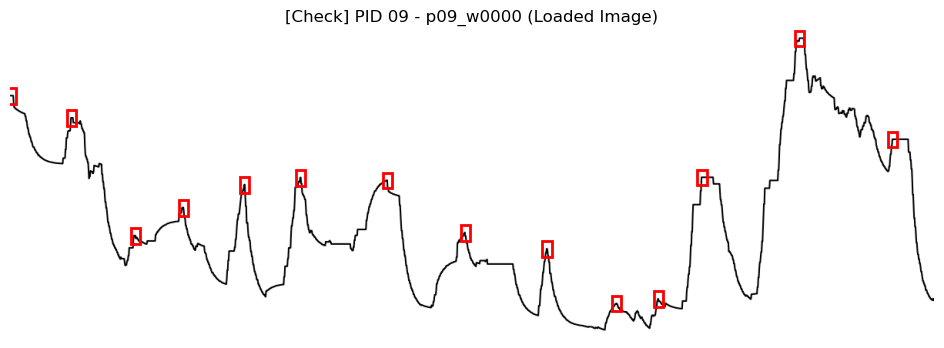

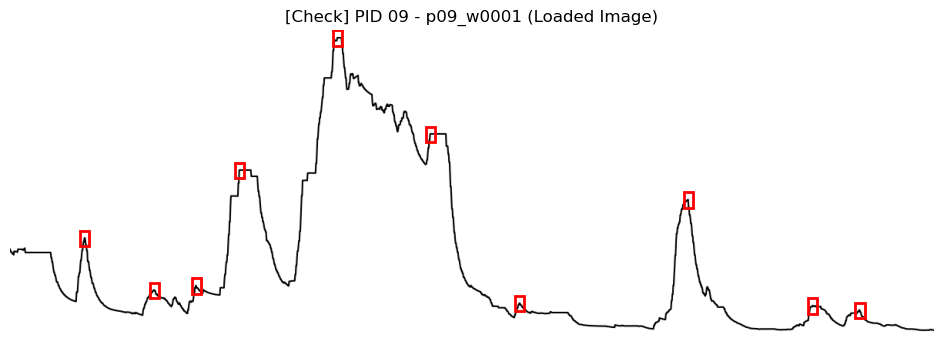

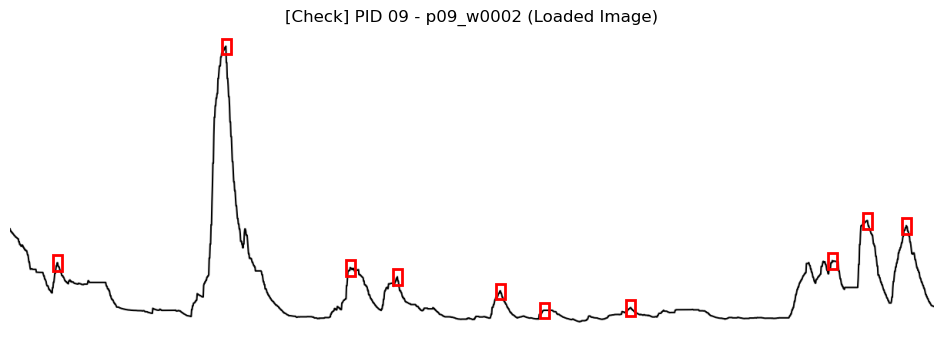

YOLO 데이터 생성:  35%|███▌      | 6/17 [01:42<03:11, 17.40s/it]

PID 09: 329개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 10 범위 정보]
  - Raw 범위: 210180 ~ 4214240
  - GT 범위 : 210330 ~ 3239420
  - 적용 구간 (Intersection): 210330 ~ 3239420

[PID 10] Peak 간격 분석:
  - 평균: 1.45 sec
  - 최대: 8.70 sec
  - 최소: 0.14 sec


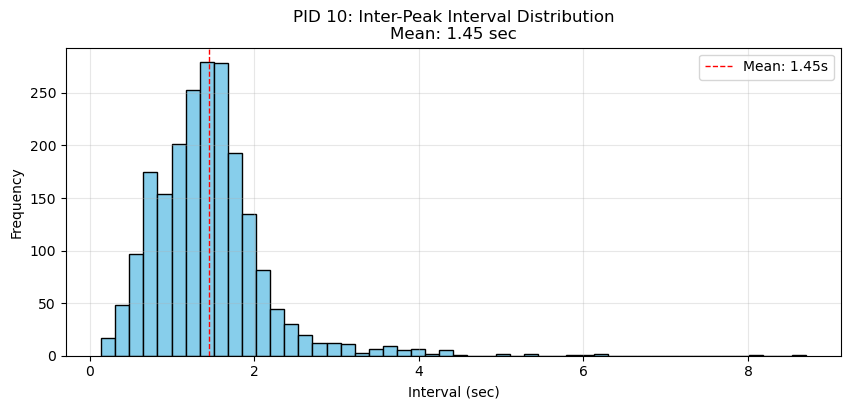

  [!] 5초 이상 간격 9개 발견 (Max: 8.70s)


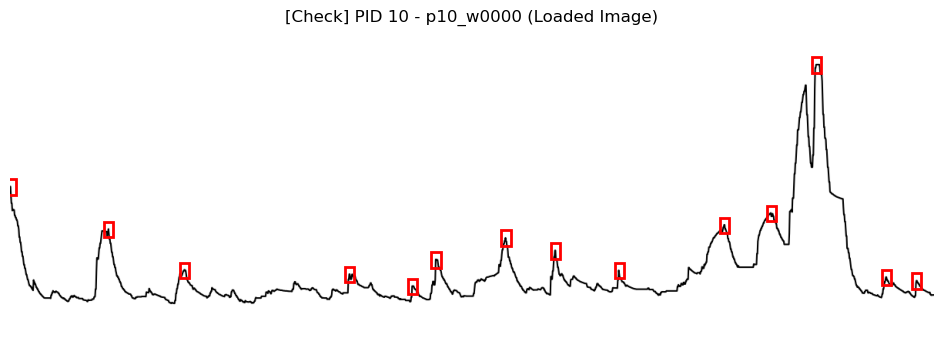

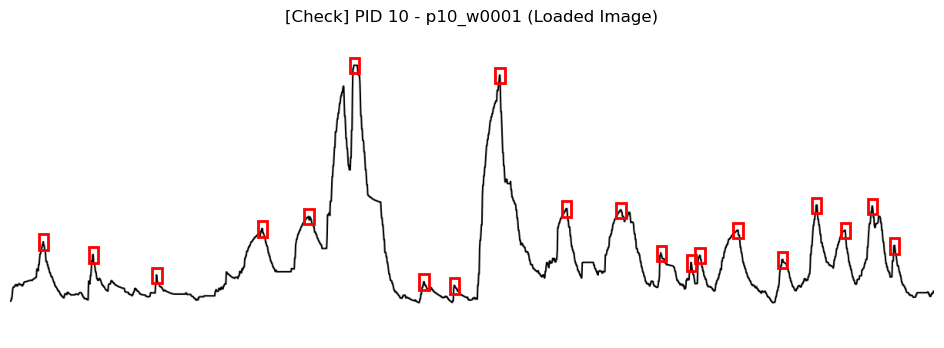

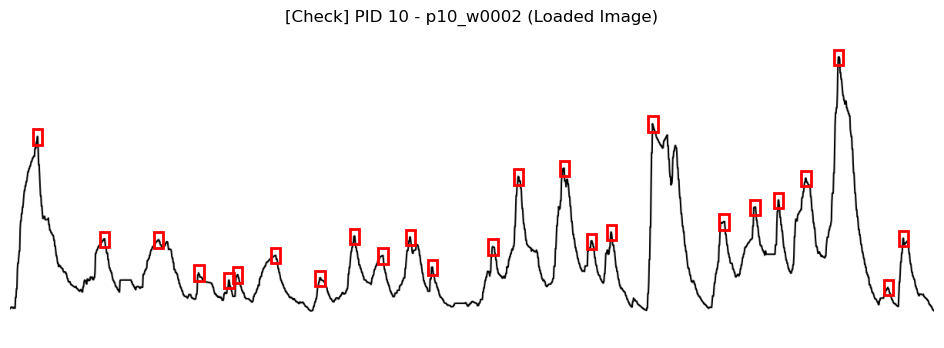

YOLO 데이터 생성:  41%|████      | 7/17 [02:00<02:53, 17.32s/it]

PID 10: 298개 윈도우 생성 완료. (NaN 스킵: 3개)

[PID 11 범위 정보]
  - Raw 범위: 179530 ~ 4179520
  - GT 범위 : 182030 ~ 3359620
  - 적용 구간 (Intersection): 182030 ~ 3359620

[PID 11] Peak 간격 분석:
  - 평균: 1.43 sec
  - 최대: 18.00 sec
  - 최소: 0.19 sec


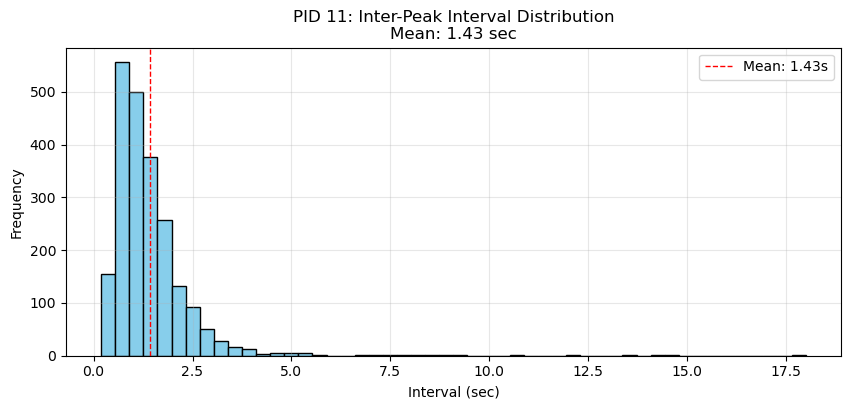

  [!] 5초 이상 간격 29개 발견 (Max: 18.00s)


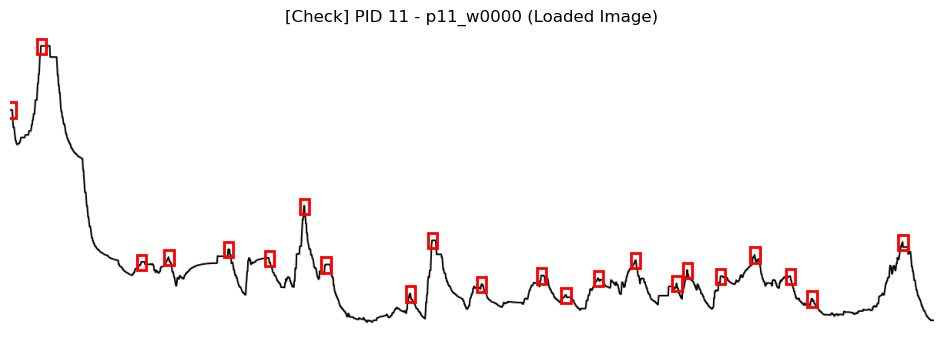

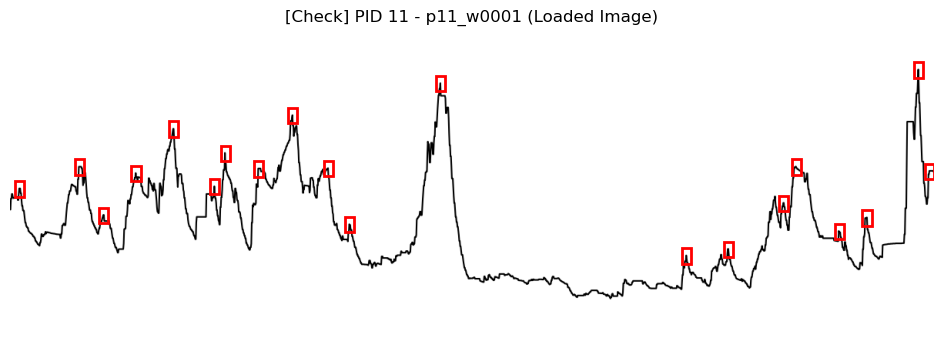

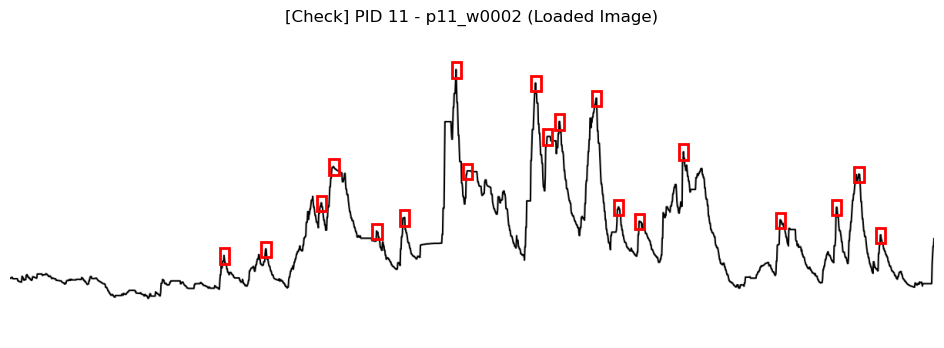

YOLO 데이터 생성:  47%|████▋     | 8/17 [02:16<02:34, 17.12s/it]

PID 11: 316개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 12 범위 정보]
  - Raw 범위: 251390 ~ 4265400
  - GT 범위 : 252580 ~ 3238540
  - 적용 구간 (Intersection): 252580 ~ 3238540

[PID 12] Peak 간격 분석:
  - 평균: 1.68 sec
  - 최대: 53.07 sec
  - 최소: 0.15 sec


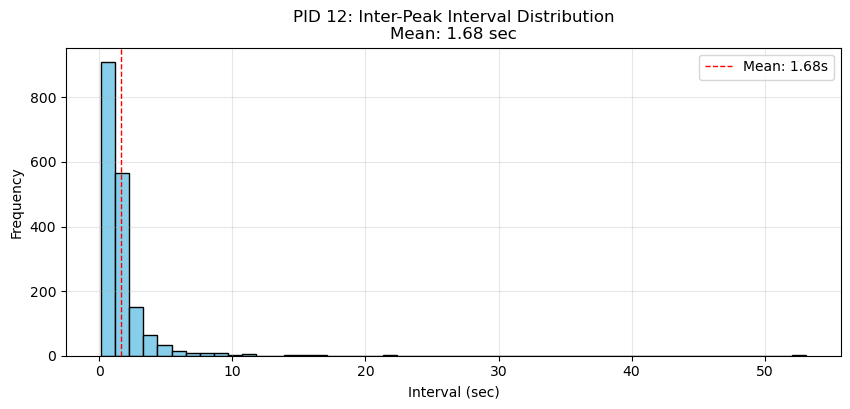

  [!] 5초 이상 간격 59개 발견 (Max: 53.07s)


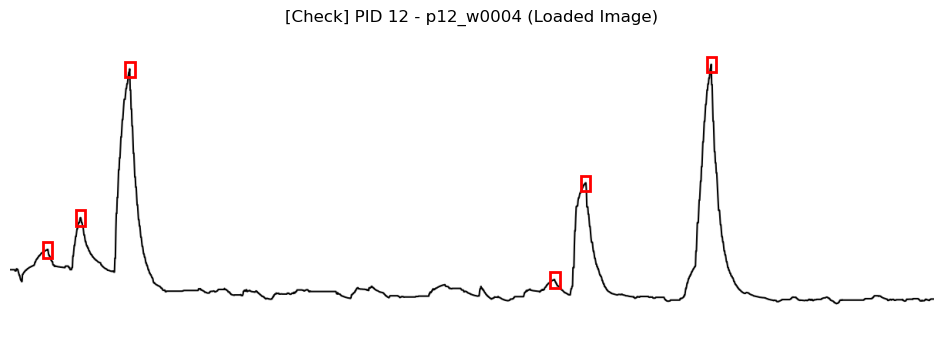

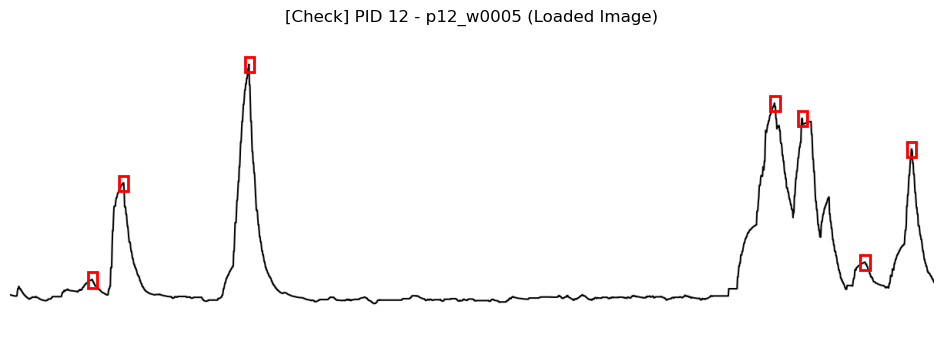

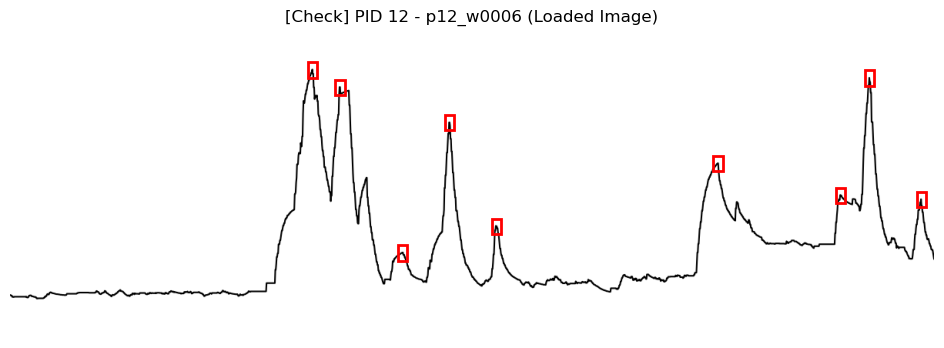

YOLO 데이터 생성:  53%|█████▎    | 9/17 [02:32<02:14, 16.76s/it]

PID 12: 290개 윈도우 생성 완료. (NaN 스킵: 4개)

[PID 13 범위 정보]
  - Raw 범위: 73030 ~ 4097930
  - GT 범위 : 76480 ~ 3419200
  - 적용 구간 (Intersection): 76480 ~ 3419200

[PID 13] Peak 간격 분석:
  - 평균: 1.29 sec
  - 최대: 13.37 sec
  - 최소: 0.13 sec


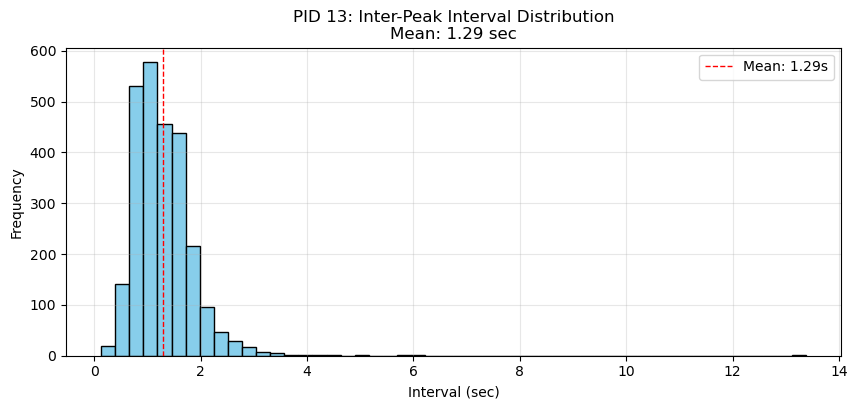

  [!] 5초 이상 간격 4개 발견 (Max: 13.37s)


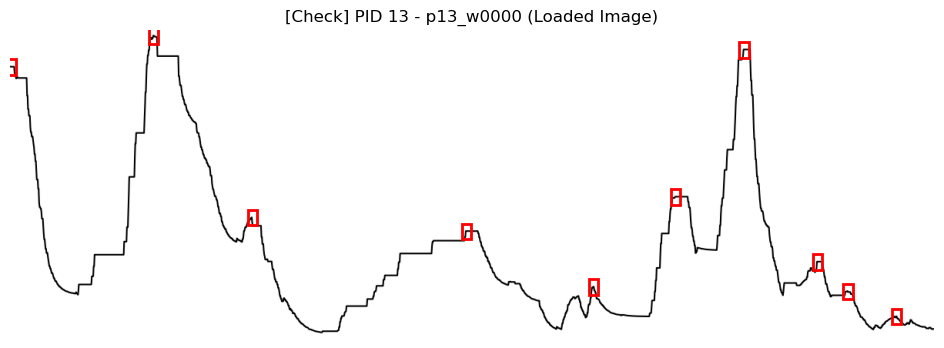

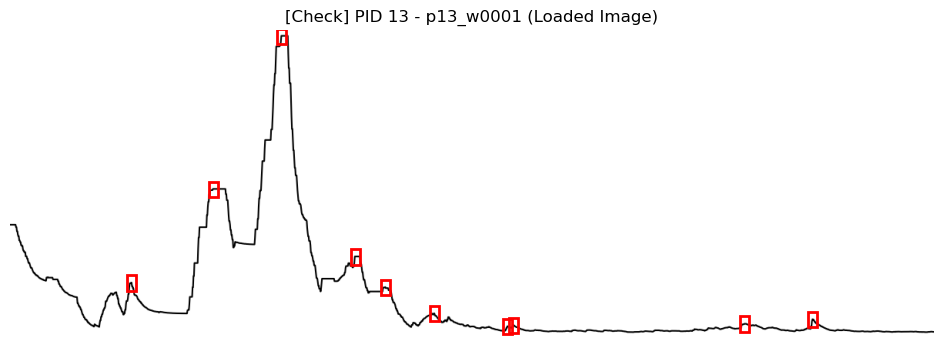

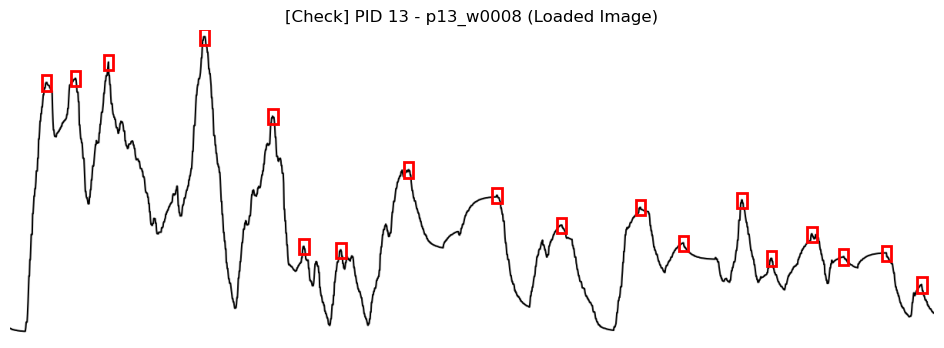

YOLO 데이터 생성:  59%|█████▉    | 10/17 [02:50<02:00, 17.21s/it]

PID 13: 327개 윈도우 생성 완료. (NaN 스킵: 6개)

[PID 14 범위 정보]
  - Raw 범위: 0 ~ 3999990
  - GT 범위 : 1550 ~ 3298480
  - 적용 구간 (Intersection): 1550 ~ 3298480

[PID 14] Peak 간격 분석:
  - 평균: 1.13 sec
  - 최대: 14.96 sec
  - 최소: 0.17 sec


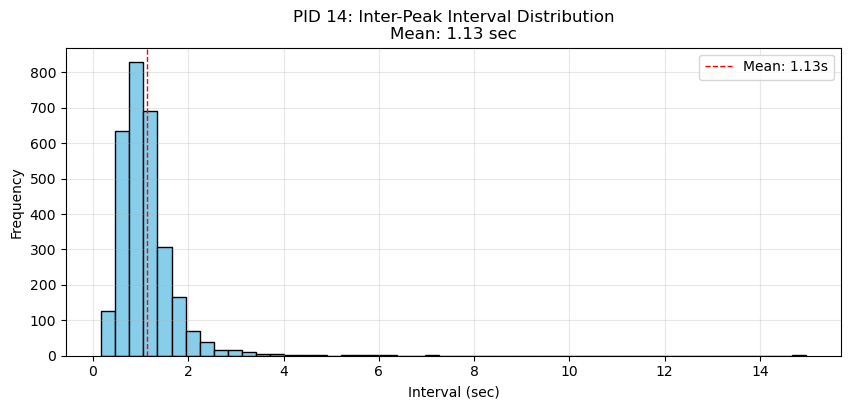

  [!] 5초 이상 간격 9개 발견 (Max: 14.96s)


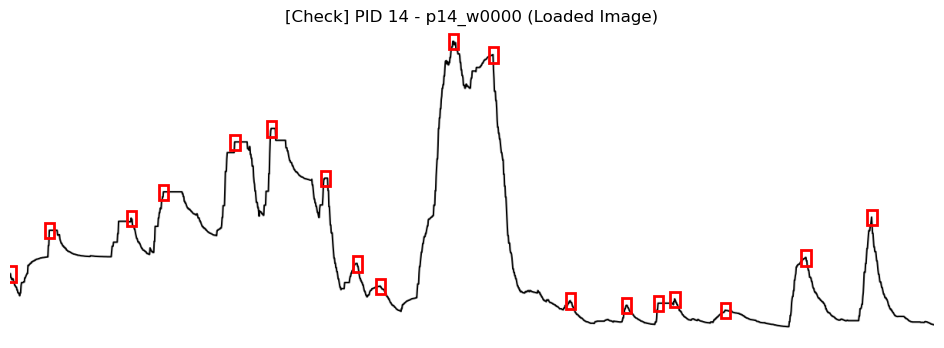

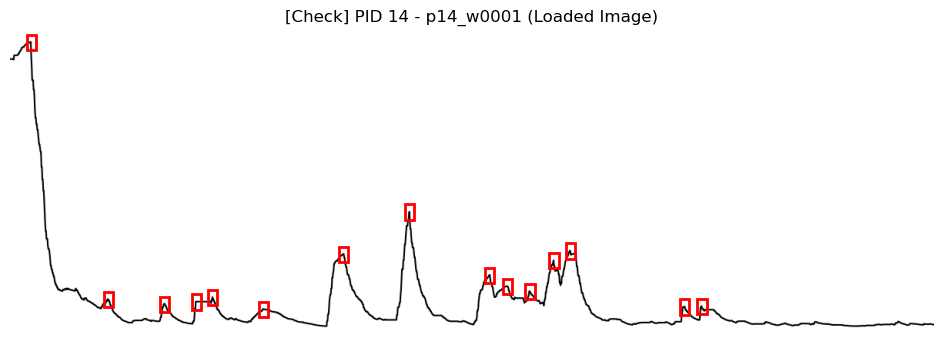

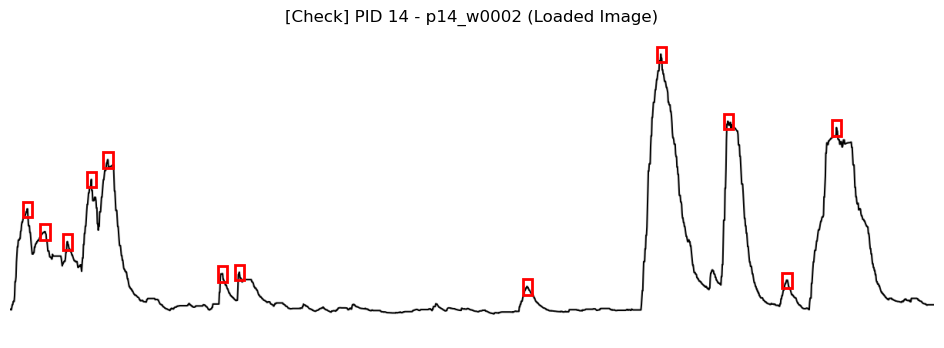

YOLO 데이터 생성:  65%|██████▍   | 11/17 [03:05<01:37, 16.27s/it]

PID 14: 328개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 15 범위 정보]
  - Raw 범위: 0 ~ 3999990
  - GT 범위 : 420 ~ 3298700
  - 적용 구간 (Intersection): 420 ~ 3298700

[PID 15] Peak 간격 분석:
  - 평균: 1.47 sec
  - 최대: 5.72 sec
  - 최소: 0.16 sec


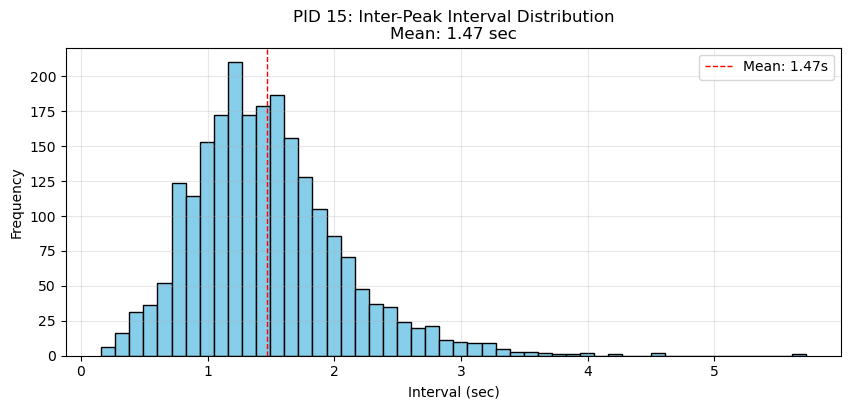

  [!] 5초 이상 간격 1개 발견 (Max: 5.72s)


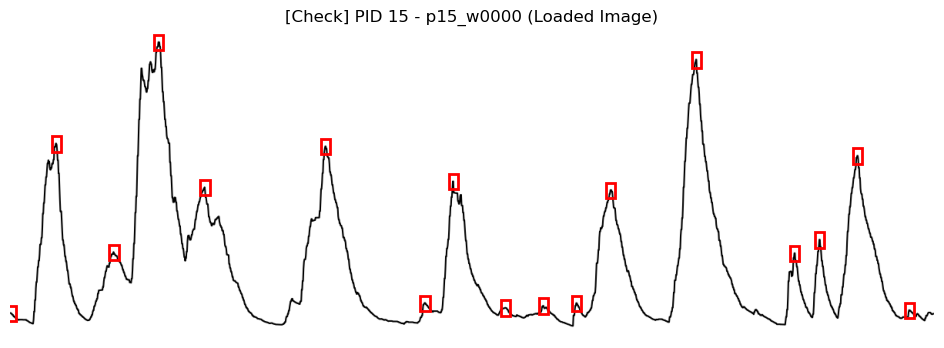

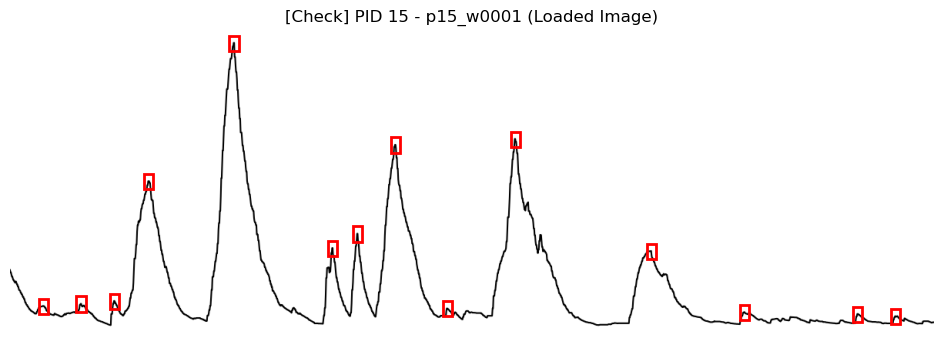

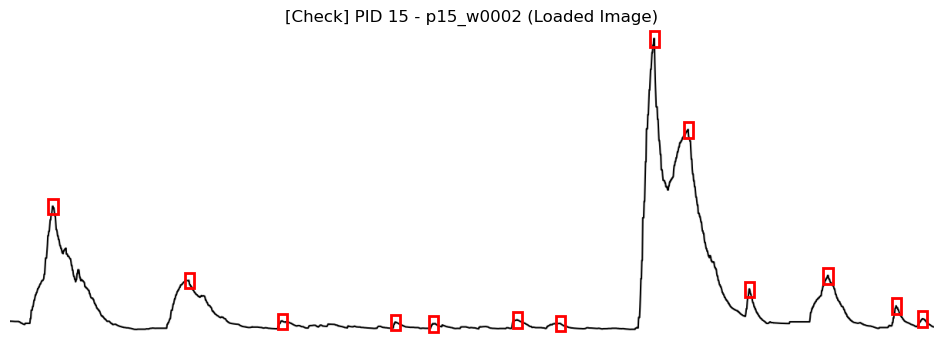

YOLO 데이터 생성:  71%|███████   | 12/17 [03:18<01:17, 15.41s/it]

PID 15: 328개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 16 범위 정보]
  - Raw 범위: 0 ~ 3999990
  - GT 범위 : 250 ~ 3059850
  - 적용 구간 (Intersection): 250 ~ 3059850

[PID 16] Peak 간격 분석:
  - 평균: 1.30 sec
  - 최대: 46.81 sec
  - 최소: 0.16 sec


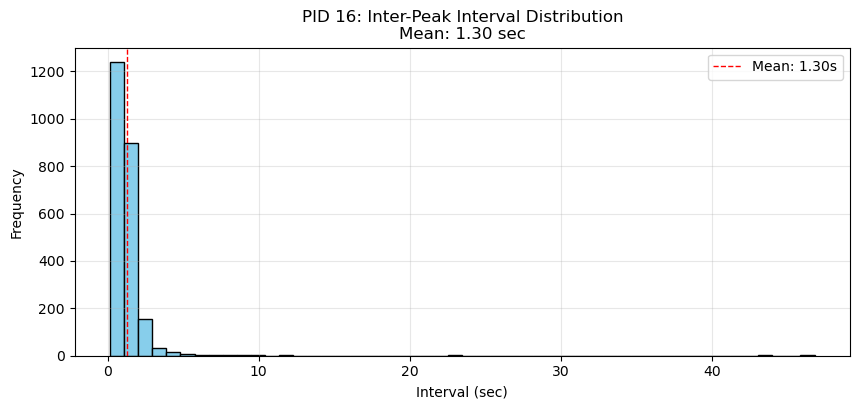

  [!] 5초 이상 간격 18개 발견 (Max: 46.81s)


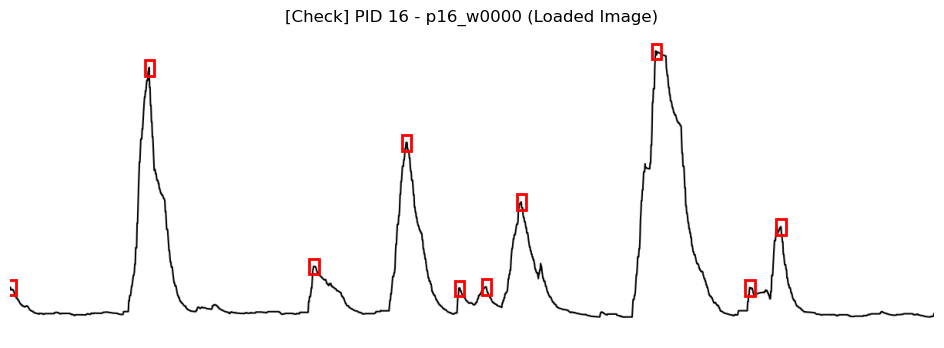

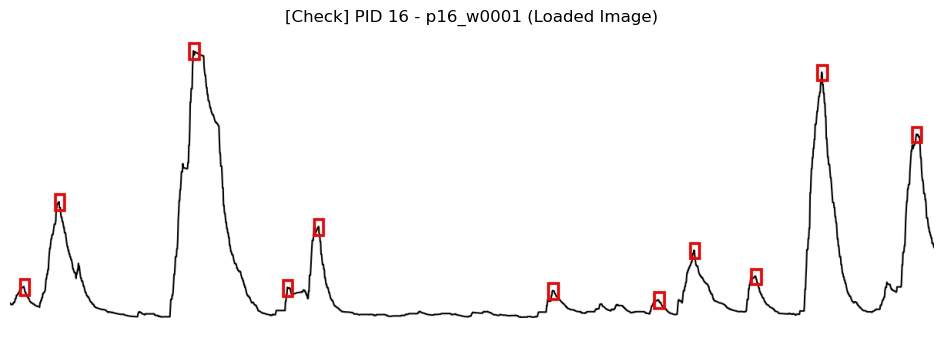

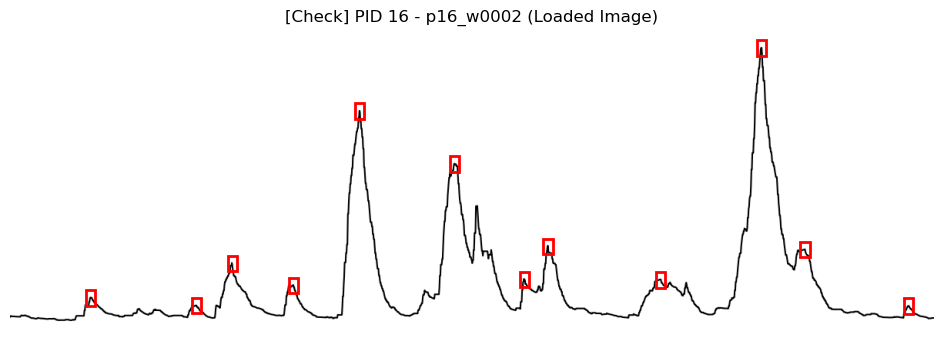

YOLO 데이터 생성:  76%|███████▋  | 13/17 [03:34<01:02, 15.66s/it]

PID 16: 282개 윈도우 생성 완료. (NaN 스킵: 22개)

[PID 17 범위 정보]
  - Raw 범위: 53970 ~ 4068190
  - GT 범위 : 60990 ~ 3477950
  - 적용 구간 (Intersection): 60990 ~ 3477950

[PID 17] Peak 간격 분석:
  - 평균: 0.92 sec
  - 최대: 6.51 sec
  - 최소: 0.15 sec


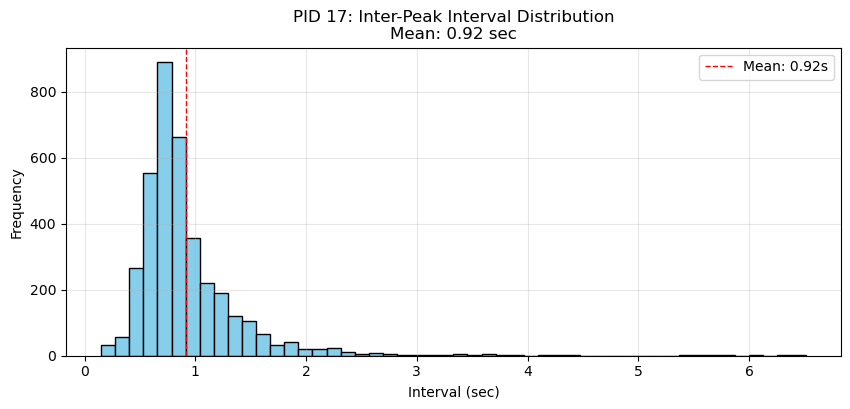

  [!] 5초 이상 간격 8개 발견 (Max: 6.51s)


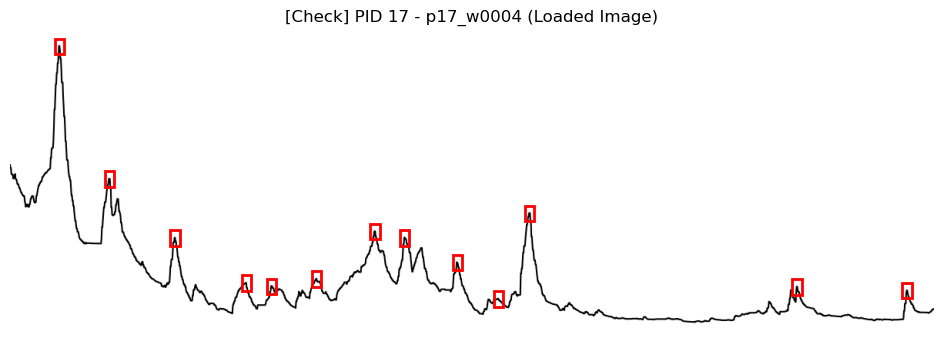

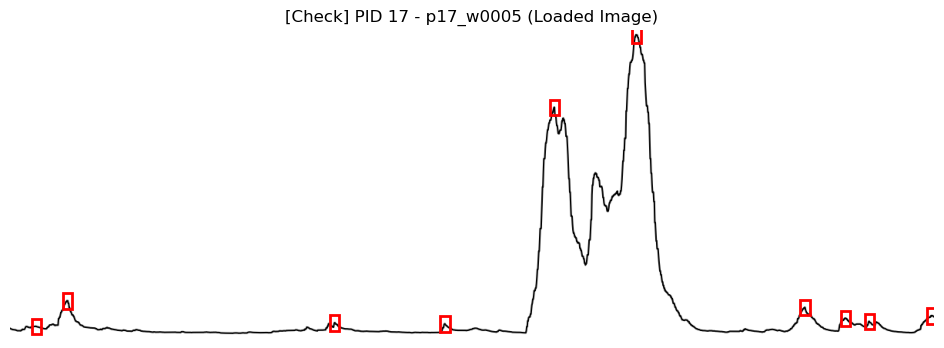

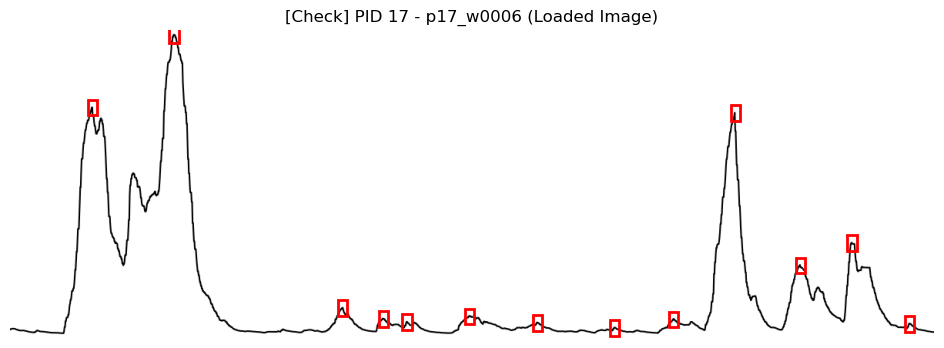

YOLO 데이터 생성:  82%|████████▏ | 14/17 [03:52<00:49, 16.37s/it]

PID 17: 336개 윈도우 생성 완료. (NaN 스킵: 4개)

[PID 18 범위 정보]
  - Raw 범위: 94810 ~ 4102240
  - GT 범위 : 225980 ~ 3419730
  - 적용 구간 (Intersection): 225980 ~ 3419730

[PID 18] Peak 간격 분석:
  - 평균: 1.36 sec
  - 최대: 10.34 sec
  - 최소: 0.14 sec


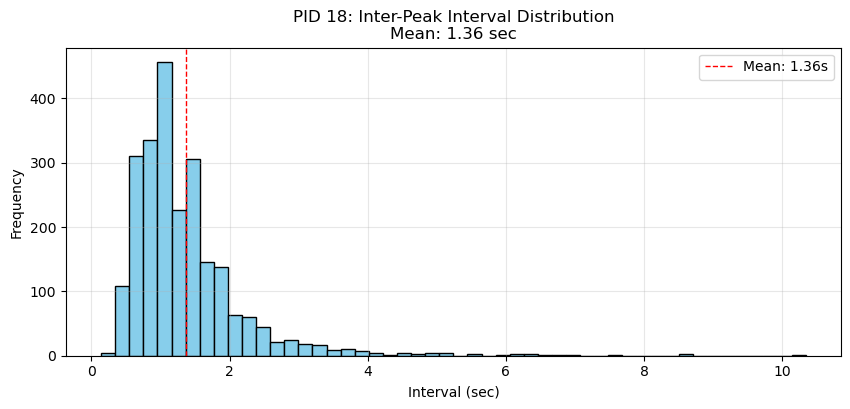

  [!] 5초 이상 간격 19개 발견 (Max: 10.34s)


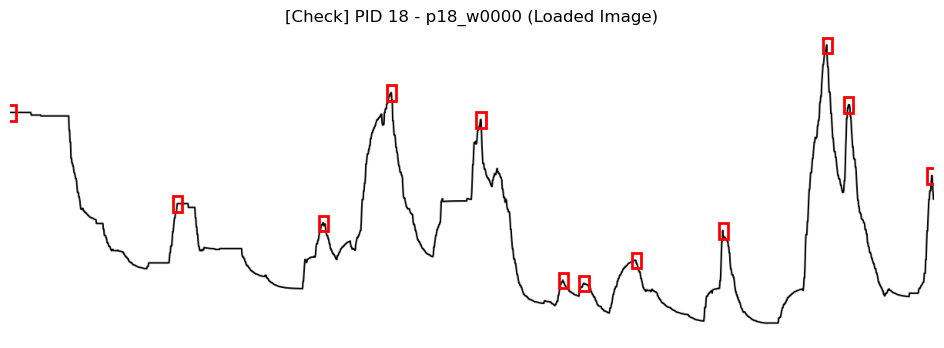

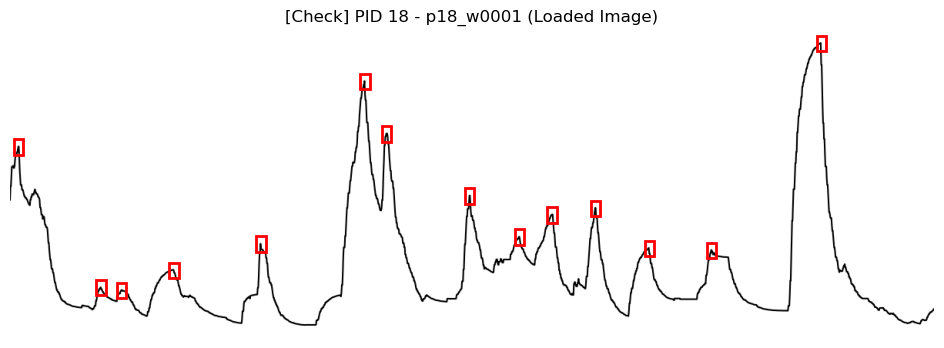

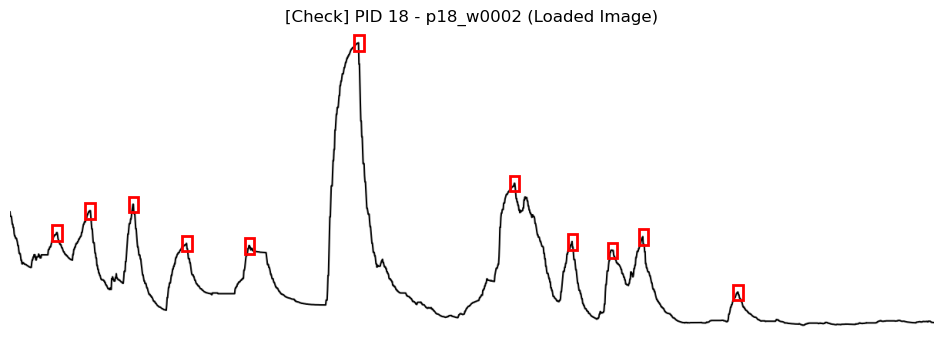

YOLO 데이터 생성:  88%|████████▊ | 15/17 [04:10<00:33, 16.80s/it]

PID 18: 318개 윈도우 생성 완료. (NaN 스킵: 0개)

[PID 19 범위 정보]
  - Raw 범위: 10 ~ 4000000
  - GT 범위 : 530 ~ 3357730
  - 적용 구간 (Intersection): 530 ~ 3357730

[PID 19] Peak 간격 분석:
  - 평균: 1.08 sec
  - 최대: 21.10 sec
  - 최소: 0.15 sec


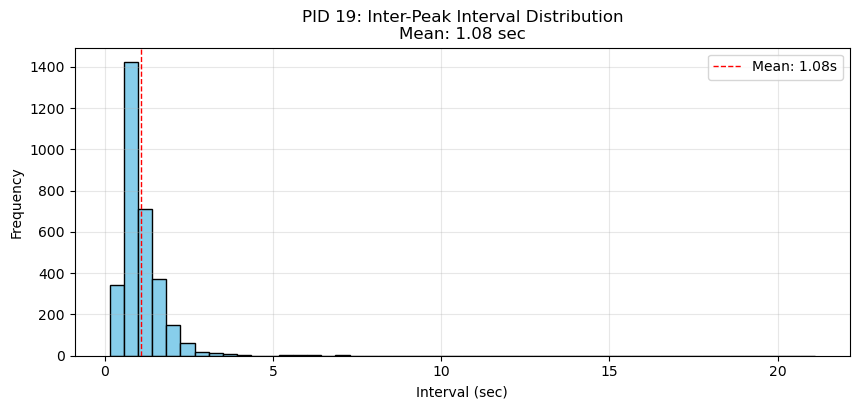

  [!] 5초 이상 간격 11개 발견 (Max: 21.10s)


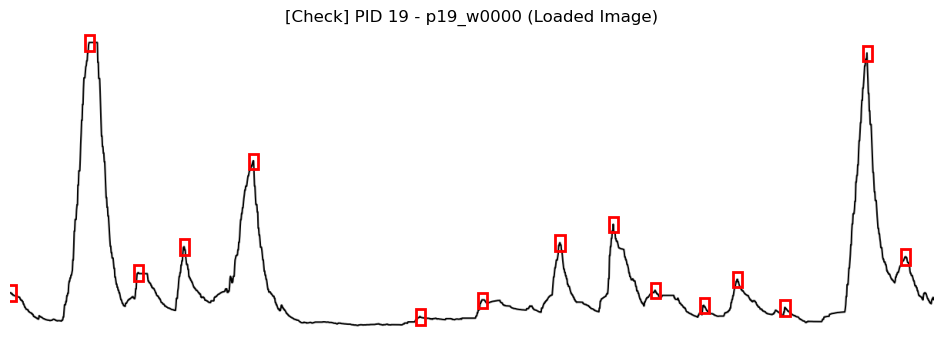

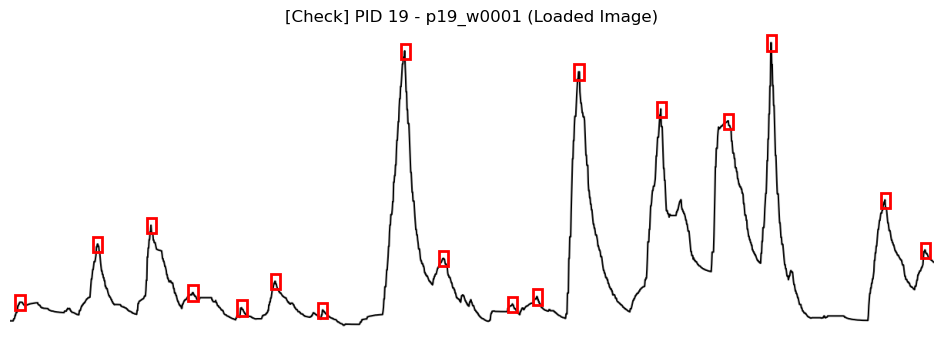

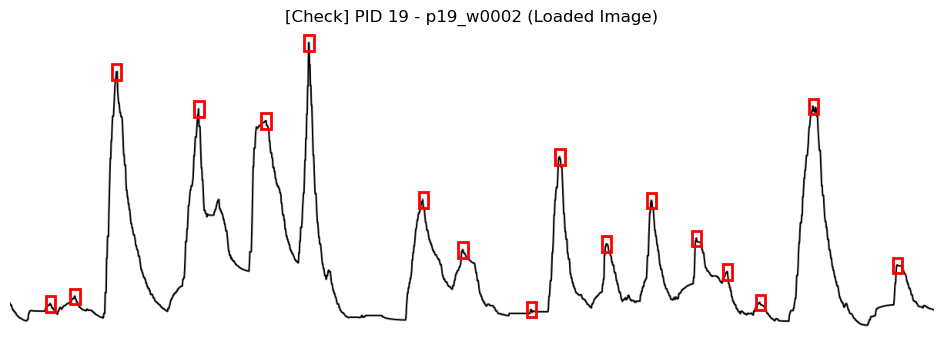

YOLO 데이터 생성:  94%|█████████▍| 16/17 [04:28<00:17, 17.09s/it]

PID 19: 330개 윈도우 생성 완료. (NaN 스킵: 4개)

[PID 20 범위 정보]
  - Raw 범위: 0 ~ 4047180
  - GT 범위 : 359460 ~ 3118860
  - 적용 구간 (Intersection): 359460 ~ 3118860

[PID 20] Peak 간격 분석:
  - 평균: 1.16 sec
  - 최대: 14.47 sec
  - 최소: 0.15 sec


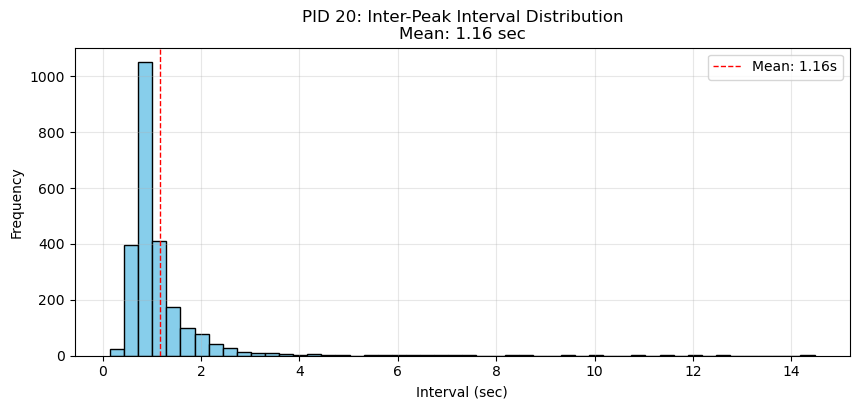

  [!] 5초 이상 간격 31개 발견 (Max: 14.47s)


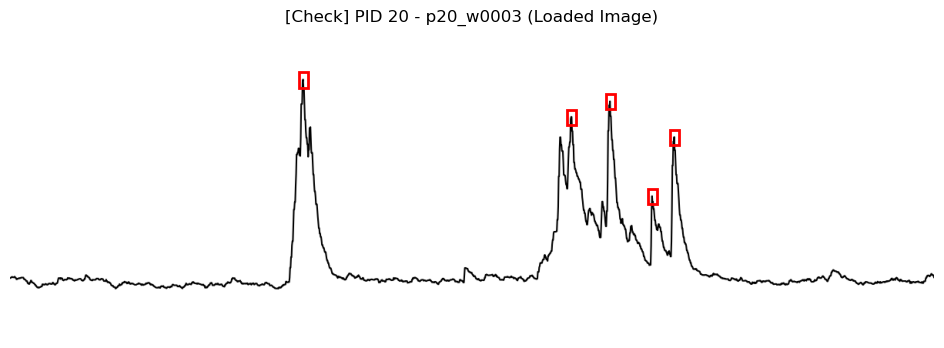

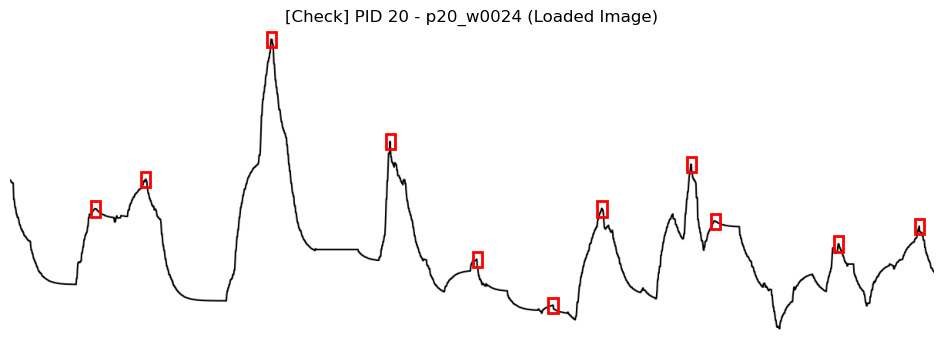

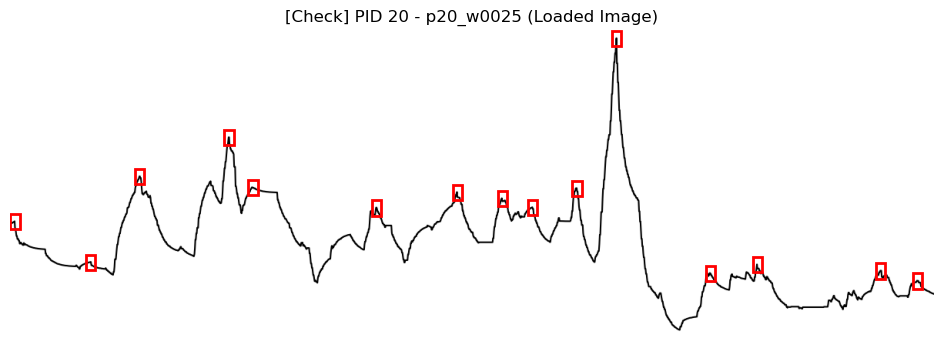

YOLO 데이터 생성: 100%|██████████| 17/17 [04:42<00:00, 16.59s/it]

PID 20: 251개 윈도우 생성 완료. (NaN 스킵: 23개)


In [17]:
# 단계 3 실행
print(f"YOLO 데이터 생성 시작... Window={WINDOW_SIZE}, Stride={STRIDE}")
for pid in tqdm(PIDS, desc="YOLO 데이터 생성"):
    generate_yolo_data(pid, WINDOW_SIZE, STRIDE)